# MovieLens Recommender System: Interaction-Based and Semantic Recommendations

## 1. Business Understanding

### 1.1 Problem

MovieLens is a movie recommendation environment operated by GroupLens. The core business challenge addressed in this project is information overload: the dataset contains 100836 ratings across 9742 movies from 610 users, but each user has rated only a small fraction of the available catalogue. This creates a sparse user-item interaction matrix, which is one of the central challenges in recommender systems.

Without a recommender system, users may spend more time searching for relevant content, miss movies they would probably enjoy, and become less engaged with the platform. From a business perspective, a good recommender system should increase the relevance of suggested movies, reduce search effort and support user retention.

The dataset contains explicit ratings on a five-star scale and free-text tagging activity collected between March 29, 1996 and September 24, 2018. Users are anonymised and no demographic information is available. The data is distributed across four files: `ratings.csv`, `movies.csv`, `tags.csv` and `links.csv`.

In this assignment, the goal is to compare different data-driven recommendation approaches and identify which ones produce the most useful top-N movie recommendations. The first part focuses on interaction-based methods such as Association Rules, Collaborative Filtering, Matrix Factorization, BPR and Neural Collaborative Filtering. The second part extends the system with content-based and semantic retrieval methods using movie metadata and a RAG-oriented pipeline.

### 1.2 Why Recommendations Matter to a Business

Personalised recommendations create value by connecting users with relevant content more quickly. Users who receive useful suggestions are more likely to interact with the platform, rate more movies and return in future sessions. Each new interaction also improves the data available for future recommendations, creating a feedback loop between user engagement and model quality.

At catalogue level, recommender systems can also help reduce the over-exposure of only the most popular movies. In sparse datasets, many long-tail items receive few interactions and may be ignored by popularity-based approaches. A well-designed recommender system should therefore balance relevance with the ability to surface less obvious but still suitable movies.

The cold-start problem is also a relevant operational concern. New users have no rating history, and new movies may enter the catalogue without interactions. Interaction-based models may struggle in these cases, while content-based features such as genres, tags and textual metadata can help mitigate this limitation.

### 1.3 Success Criteria and ML Objectives

| Business Goal | Success Criterion | ML Objective | Main Metric |
|---|---|---|---|
| Users find movies they enjoy | Recommended movies are relevant | Rank unseen movies according to predicted user preference | Precision@3 |
| Users do not miss relevant content | Relevant held-out movies appear in the recommendation list | Retrieve as many relevant items as possible in the top recommendations | Recall@3 |
| Recommendations are useful in practice | Already-rated movies are not recommended again | Generate top-3 unseen recommendations per user | Precision@3 / Recall@3 |
| Models are comparable | Different methods are evaluated under the same split | Compare AR, CF, MF, BPR, NCF and RAG-based retrieval | Precision@3 / Recall@3 |
| Explicit ratings are modelled when appropriate | Predicted ratings approximate held-out ratings | Estimate user-item rating scores | RMSE / MAE as secondary metrics |

The ML problem takes two complementary forms depending on how the feedback signal is used:

- **Explicit feedback scenario**: ratings from 0.5 to 5.0 are preserved and used to estimate user preference scores. Rating prediction metrics such as RMSE and MAE may be reported as secondary diagnostics, especially for matrix factorization models.
- **Binary feedback scenario**: ratings are transformed into implicit positive feedback. In this notebook, a movie is considered relevant when the user rated it with `rating >= 4`. The task becomes a ranking problem: for each user, the model should place relevant unseen movies as high as possible in the recommendation list.

Since the assignment focuses on top-3 recommendations, the main evaluation metrics are **Precision@3** and **Recall@3**. These metrics are more aligned with the operational goal of recommending a short list of movies than general prediction metrics such as RMSE or MAE.

All models are evaluated on held-out user interactions, and already-rated movies are excluded from the recommendation candidates whenever possible.

## 2. Data Understanding

Before building any model, we need to understand the data we are working with. This section characterises the `ratings` table – the core table for interaction-based recommendation – focusing on its structure, sparsity, rating distribution and user activity patterns. These properties directly inform the modelling and evaluation choices made in later sections.

### 2.1 Imports and Data Loading


This section imports the libraries required for data analysis, visualisation and recommendation modelling. We also load the four MovieLens files used in the project: `ratings.csv`, `movies.csv`, `tags.csv` and `links.csv`.

The `ratings` table is the core interaction table for the first part of the assignment, while `movies`, `tags` and `links` provide metadata that will later be useful for content-based and RAG-oriented recommendations.

In [74]:
# Data manipulation
import numpy as np
import pandas as pd

# Reproducibility

# A fixed random seed ensures that sampling, train/test splits and
# other random operations can be reproduced in later executions.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



# Model selection and preprocessing

# train_test_split will be used to create validation/test partitions.
# MinMaxScaler may be useful later if numerical scores need to be scaled.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


# Recommendation-related methods

# Apriori and association_rules are used for Association Rule Mining.
# cosine_similarity is used for memory-based Collaborative Filtering.
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity


# Sparse matrix representation

# Sparse matrices are important for recommender systems because
# the user-item matrix is usually very sparse.
import scipy.sparse as sp
from scipy.sparse import csr_matrix


# Statistical analysis

# scipy.stats is used for exploratory statistical checks,
# such as analysing power-law-like behaviour in basket sizes.
import scipy.stats as stats


# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


# Warnings
import warnings
warnings.filterwarnings("ignore")


# Load MovieLens data
ratings = pd.read_csv("ratings.csv")
movies  = pd.read_csv("movies.csv")
tags    = pd.read_csv("tags.csv")
links   = pd.read_csv("links.csv")


# The ratings table is the core table for interaction-based recommendation.
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


### 2.2. Data Quality and Structure


Before modelling, it is necessary to check whether the dataset contains structural problems that could affect the analysis or evaluation. In this section, we inspect the dimensions of each table, missing values, duplicated user–movie ratings and the main feature types available in the dataset.

The `ratings` table is particularly important because it contains the user–movie interactions used by the recommendation models.

In [75]:
# Store all loaded tables in a dictionary for easier inspection
tables = {
    "ratings": ratings,
    "movies": movies,
    "tags": tags,
    "links": links
}


# This summary confirms that all expected MovieLens files were loaded
# and shows the structure of each table.
table_summary = pd.DataFrame({
    "table": list(tables.keys()),
    "rows": [df.shape[0] for df in tables.values()],
    "columns": [df.shape[1] for df in tables.values()],
    "column_names": [", ".join(df.columns) for df in tables.values()]
})

display(table_summary)


# Missing values may require imputation or filtering before modelling.
# We check all tables, although ratings is the core interaction table.
missing_summary = pd.concat(
    {name: df.isnull().sum() for name, df in tables.items()},
    axis=1
).T

display(missing_summary)


# In the ratings table, each (userId, movieId) pair should appear at most once.
# Duplicates would distort both model training and evaluation.
duplicate_user_movie_pairs = ratings.duplicated(
    subset=["userId", "movieId"]
).sum()

print(f"Duplicate (userId, movieId) pairs in ratings: {duplicate_user_movie_pairs}")


# This table summarises the variables that will be most relevant
# for the recommendation and semantic retrieval tasks.
feature_description = pd.DataFrame({
    "Feature": ["userId", "movieId", "rating", "timestamp", "title", "genres", "tag", "imdbId", "tmdbId"],
    "Table": ["ratings/tags", "all tables", "ratings", "ratings/tags", "movies", "movies", "tags", "links", "links"],
    "Type": ["integer", "integer", "float", "integer", "text", "text/categorical", "text", "integer", "integer"],
    "Description": [
        "Anonymised user identifier",
        "Movie identifier shared across tables",
        "Explicit user rating from 0.5 to 5.0",
        "Unix timestamp of the rating or tag",
        "Movie title, including release year when available",
        "Pipe-separated list of movie genres",
        "Free-text user-generated tag",
        "IMDb identifier for external metadata",
        "TMDb identifier for external metadata"
    ]
})

display(feature_description)

,table,rows,columns,column_names
0,ratings,100836,4,"userId, movieId, rating, timestamp"
1,movies,9742,3,"movieId, title, genres"
2,tags,3683,4,"userId, movieId, tag, timestamp"
3,links,9742,3,"movieId, imdbId, tmdbId"


,userId,movieId,rating,timestamp,title,genres,tag,imdbId,tmdbId
ratings,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
movies,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
tags,0.0,0.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN
links,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,8.0


Duplicate (userId, movieId) pairs in ratings: 0


,Feature,Table,Type,Description
0,userId,ratings/tags,integer,Anonymised user identifier
1,movieId,all tables,integer,Movie identifier shared across tables
2,rating,ratings,float,Explicit user rating from 0.5 to 5.0
3,timestamp,ratings/tags,integer,Unix timestamp of the rating or tag
4,title,movies,text,"Movie title, including release year when avail..."
5,genres,movies,text/categorical,Pipe-separated list of movie genres
6,tag,tags,text,Free-text user-generated tag
7,imdbId,links,integer,IMDb identifier for external metadata
8,tmdbId,links,integer,TMDb identifier for external metadata


The dataset was loaded successfully and contains the four expected MovieLens files. The `ratings` table is the largest and most important table for the first part of the project, since it contains the explicit user–movie interactions used by the recommendation models.

The `ratings` table has no missing values and no duplicated `(userId, movieId)` pairs. This means that each user rated each movie at most once, so no deduplication is required before modelling.

The `movies` and `tags` tables provide textual information such as titles, genres and user-generated tags. These variables are not central to the first interaction-based models, but they are important for the later content-based and RAG-oriented recommendation stage.

#### 2.2.1. Basic Characteristics

In [76]:
# Number of unique users, rated movies and observed ratings
n_users = ratings["userId"].nunique()
n_items = ratings["movieId"].nunique()
n_ratings = len(ratings)

# Sparsity of the user-item matrix
# Sparsity measures the proportion of missing user-movie interactions.
sparsity = 1 - n_ratings / (n_users * n_items)

# Rating scale
min_rating = ratings["rating"].min()
max_rating = ratings["rating"].max()

# Convert Unix timestamps to readable dates
min_date = pd.to_datetime(ratings["timestamp"], unit="s").min().date()
max_date = pd.to_datetime(ratings["timestamp"], unit="s").max().date()

# Average number of ratings per user
avg_ratings_per_user = n_ratings / n_users

# Summary table
basic_characteristics = pd.DataFrame({
    "Metric": [
        "Number of users",
        "Number of rated movies",
        "Number of ratings",
        "User-item matrix sparsity",
        "Observed interaction density",
        "Rating scale",
        "Date range",
        "Average ratings per user"
    ],
    "Value": [
        n_users,
        n_items,
        n_ratings,
        f"{sparsity:.2%}",
        f"{1 - sparsity:.2%}",
        f"{min_rating} to {max_rating}",
        f"{min_date} to {max_date}",
        f"{avg_ratings_per_user:.1f}"
    ]
})

display(basic_characteristics)

,Metric,Value
0,Number of users,610
1,Number of rated movies,9724
2,Number of ratings,100836
3,User-item matrix sparsity,98.30%
4,Observed interaction density,1.70%
5,Rating scale,0.5 to 5.0
6,Date range,1996-03-29 to 2018-09-24
7,Average ratings per user,165.3


The user-item matrix is extremely sparse. With 610 users and 9724 rated movies, the theoretical maximum number of user-movie ratings would be 5931640, but only 100,836 ratings are observed. This means that approximately 98.3% of the matrix is empty, or equivalently, only about 1.7% of all possible user-movie interactions are known.

In practice, the average user has rated around 165 movies out of 9724 available rated movies, which is less than 2% of the catalogue. This confirms that each user provides only a small partial view of their preferences.

This sparsity is not just a dataset characteristic; it is the central modelling challenge in recommender systems. Models must infer preferences for thousands of unseen movies from a small number of observed interactions. This affects model choice, evaluation strategy and the handling of cold-start cases.

### 2.2.2 Rating Distribution

**Question:** Are ratings evenly distributed across the 0.5–5.0 scale, or are users biased towards positive ratings?

Understanding the rating distribution is important because the original ratings may be used as explicit feedback, while a binary version of the problem requires defining which ratings count as relevant.

,Metric,Value
0,Minimum rating,0.5
1,Maximum rating,5.0
2,Most common rating,4.0
3,Mean rating,3.5
4,Median rating,3.5
5,Ratings >= 4,48580.0
6,Ratings < 2,5972.0


,rating,count
0,0.5,1370
1,1.0,2811
2,1.5,1791
3,2.0,7551
4,2.5,5550
5,3.0,20047
6,3.5,13136
7,4.0,26818
8,4.5,8551
9,5.0,13211


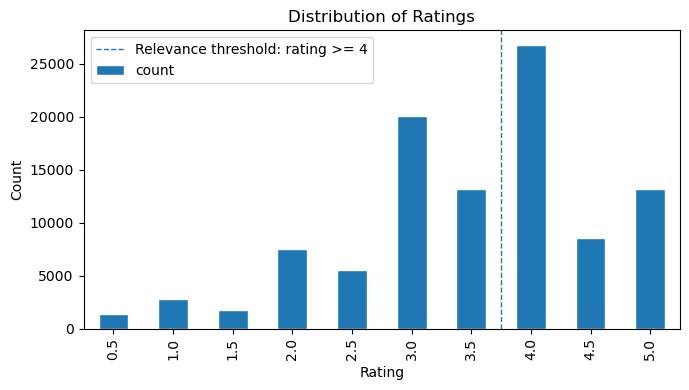

In [77]:
# Count how many times each rating value appears
rating_counts = ratings["rating"].value_counts().sort_index()

# Summary statistics for the rating variable
rating_summary = pd.DataFrame({
    "Metric": [
        "Minimum rating",
        "Maximum rating",
        "Most common rating",
        "Mean rating",
        "Median rating",
        "Ratings >= 4",
        "Ratings < 2"
    ],
    "Value": [
        ratings["rating"].min(),
        ratings["rating"].max(),
        rating_counts.idxmax(),
        round(ratings["rating"].mean(), 2),
        ratings["rating"].median(),
        int((ratings["rating"] >= 4).sum()),
        int((ratings["rating"] < 2).sum())
    ]
})

display(rating_summary)

# Display rating frequency table
rating_distribution = rating_counts.reset_index()
rating_distribution.columns = ["rating", "count"]

display(rating_distribution)

# Plot rating distribution
fig, ax = plt.subplots(figsize=(7, 4))

rating_counts.plot(
    kind="bar",
    ax=ax,
    edgecolor="white"
)

# Mark the relevance threshold used later in the binary scenario
ax.axvline(
    x=list(rating_counts.index).index(4.0) - 0.5,
    linestyle="--",
    linewidth=1,
    label="Relevance threshold: rating >= 4"
)

ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_title("Distribution of Ratings")
ax.legend()

plt.tight_layout()
plt.show()

**Are users biased towards positive or negative ratings?**

The rating distribution shows a clear positive skew. The most common rating is 4.0, with 26,818 observations, while both the mean and the median are around 3.5. Ratings below 2.0 are relatively rare, with 5972 observations, compared with 48,580 ratings equal to or above 4.0.

This distribution is important for the modelling stage because explicit and binary recommendation settings use the rating signal differently. In the explicit feedback scenario, the original 0.5–5.0 ratings are preserved as preference scores. In the binary scenario, any rating confirms that the user interacted with a movie, but relevance is defined more strictly: a movie is considered relevant only when `rating >= 4`.

This avoids treating low ratings as positive preferences during evaluation, while still allowing interaction-based methods to use the existence of ratings as evidence of user activity.

#### 2.2.3 Basket Size Distribution

**Question:** How many movies does each user rate, and is user activity evenly distributed?

In recommender systems, the number of ratings made by each user is often called the user's **basket size** or **profile size**. This measure is important because users with many ratings provide richer information for the model, while users with shorter histories are harder to personalise.

This analysis helps us understand whether the dataset contains balanced user activity or whether a small number of highly active users dominate the available interactions. It also helps assess whether the basket size distribution shows a heavy-tailed or power-law-like pattern, as requested in the assignment.

,Metric,Value
0,Minimum ratings per user,20.0
1,Maximum ratings per user,2698.0
2,Mean ratings per user,165.3
3,Median ratings per user,70.0
4,25th percentile,35.0
5,75th percentile,168.0
6,90th percentile,400.0
7,95th percentile,610.0
8,99th percentile,1256.0


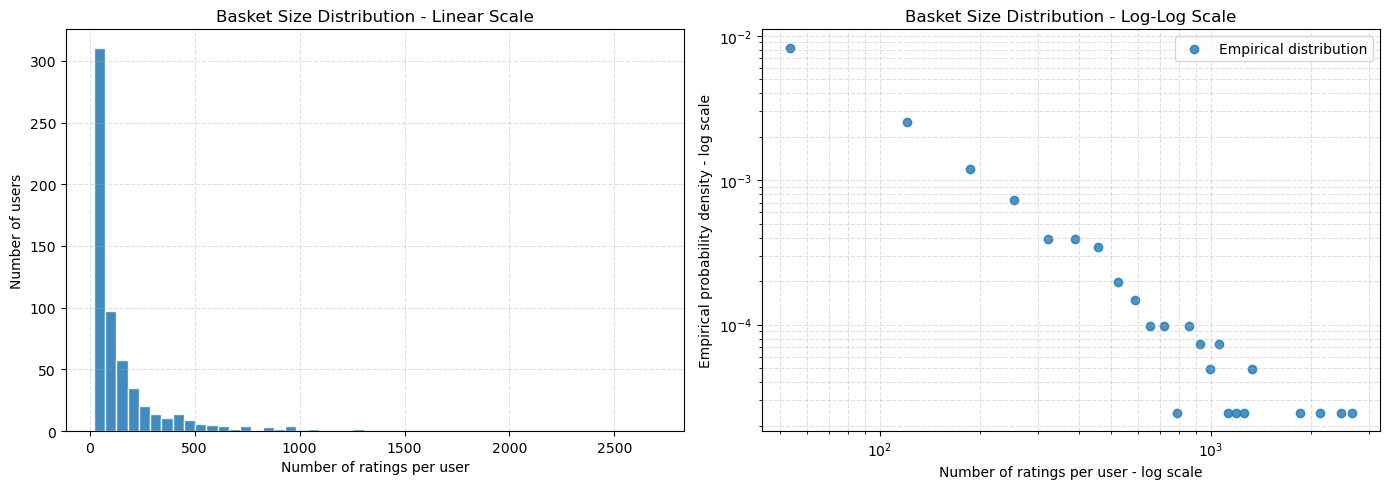

In [78]:
# Basket size: number of movies rated by each user
basket_sizes = ratings.groupby("userId")["movieId"].count()

# Summary statistics for user activity
basket_summary = pd.DataFrame({
    "Metric": [
        "Minimum ratings per user",
        "Maximum ratings per user",
        "Mean ratings per user",
        "Median ratings per user",
        "25th percentile",
        "75th percentile",
        "90th percentile",
        "95th percentile",
        "99th percentile"
    ],
    "Value": [
        int(basket_sizes.min()),
        int(basket_sizes.max()),
        round(basket_sizes.mean(), 1),
        int(basket_sizes.median()),
        int(np.percentile(basket_sizes, 25)),
        int(np.percentile(basket_sizes, 75)),
        int(np.percentile(basket_sizes, 90)),
        int(np.percentile(basket_sizes, 95)),
        int(np.percentile(basket_sizes, 99))
    ]
})

display(basket_summary)

# Plot basket size distribution on linear and log-log scales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale histogram
axes[0].hist(
    basket_sizes,
    bins=50,
    edgecolor="white",
    alpha=0.85
)

axes[0].set_xlabel("Number of ratings per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Basket Size Distribution - Linear Scale")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Log-log empirical distribution
counts, bin_edges = np.histogram(basket_sizes, bins=40, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Remove zero-density bins before applying log scale
valid_mask = counts > 0
log_centers = bin_centers[valid_mask]
log_counts = counts[valid_mask]

axes[1].scatter(
    log_centers,
    log_counts,
    alpha=0.8,
    label="Empirical distribution"
)

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Number of ratings per user - log scale")
axes[1].set_ylabel("Empirical probability density - log scale")
axes[1].set_title("Basket Size Distribution - Log-Log Scale")
axes[1].grid(True, which="both", linestyle="--", alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

User activity is highly unequal. Although every user has rated at least 20 movies, the most active user rated 2698 movies. The median user rated 70 movies, while the mean is around 165 ratings per user. Since the mean is much higher than the median, the distribution is strongly right-skewed.

The linear-scale histogram shows that most users have relatively small profiles, while a small number of users have very large baskets. This suggests a long-tail pattern in user activity. The log-log plot helps assess whether this distribution is compatible with a power-law-like behaviour: if the points followed an approximately straight line, this would support that interpretation.

This matters for modelling because users with many ratings are easier to personalise, while users with shorter histories provide less information and are harder to model accurately. Therefore, aggregate evaluation metrics such as Precision@3 and Recall@3 should be interpreted carefully, since they may hide performance differences between highly active and less active users.

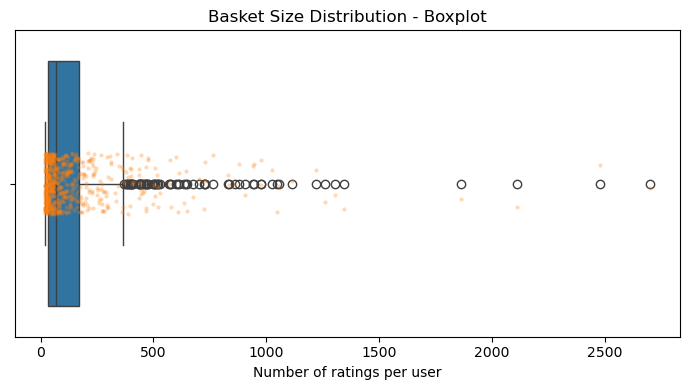

,Percentile,Ratings per user
0,P25,35
1,P50,70
2,P75,168
3,P90,400
4,P95,610
5,P99,1256


In [79]:
# Boxplot and selected percentiles for basket size distribution

fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(
    x=basket_sizes,
    ax=ax
)

sns.stripplot(
    x=basket_sizes,
    ax=ax,
    alpha=0.3,
    size=3
)

ax.set_xlabel("Number of ratings per user")
ax.set_title("Basket Size Distribution - Boxplot")

plt.tight_layout()
plt.show()

# Selected percentiles
percentiles = [25, 50, 75, 90, 95, 99]

percentile_summary = pd.DataFrame({
    "Percentile": [f"P{p}" for p in percentiles],
    "Ratings per user": [int(np.percentile(basket_sizes, p)) for p in percentiles]
})

display(percentile_summary)

The boxplot and percentile breakdown confirm the strong asymmetry in user activity. Most users are concentrated in the lower range of basket sizes, while a small number of users appear as extreme high-activity profiles.

Half of the users rated 70 movies or fewer, and 75% rated fewer than 168 movies. In contrast, the top 10% of users rated more than 400 movies, the top 5% more than 611 movies, and the top 1% more than 1256 movies.

The most active user rated 2,698 movies, which is more than twice the 99th percentile threshold. This confirms that the dataset contains a small group of users with exceptionally large profiles.

In [80]:
# Share of ratings contributed by the most active users

top_10_threshold = np.percentile(basket_sizes, 90)
top_10_users = basket_sizes[basket_sizes > top_10_threshold]

share_top_10 = top_10_users.sum() / basket_sizes.sum()

activity_concentration = pd.DataFrame({
    "Group": ["Users above P90"],
    "Number of users": [len(top_10_users)],
    "Share of all ratings": [f"{share_top_10:.2%}"]
})

display(activity_concentration)

,Group,Number of users,Share of all ratings
0,Users above P90,61,47.72%


The concentration analysis confirms this imbalance quantitatively. The 61 users above the 90th percentile represent about 10% of the user base, but they contribute 47.72% of all ratings.

This means that almost half of the available interaction data comes from a small group of very active users. As a result, recommendation models may learn more reliable preference patterns for active users than for users with shorter histories.

This is important for the evaluation stage: aggregate Precision@3 and Recall@3 may look satisfactory while hiding weaker performance for less active users. Therefore, later model comparisons should be interpreted with this imbalance in mind.

#### 2.2.4 Does Basket Size Follow a Power Law?

**Question:** Does the distribution of user basket sizes follow a power-law-like pattern?

The previous section showed that user activity is highly unequal and right-skewed. To explore whether this behaviour resembles a power law, we inspect the relationship between basket size and frequency in log-log space. A true power law would appear approximately as a straight line in this representation.

This is only an exploratory diagnostic. A formal confirmation of a power law would require fitting and comparing alternative heavy-tailed distributions.

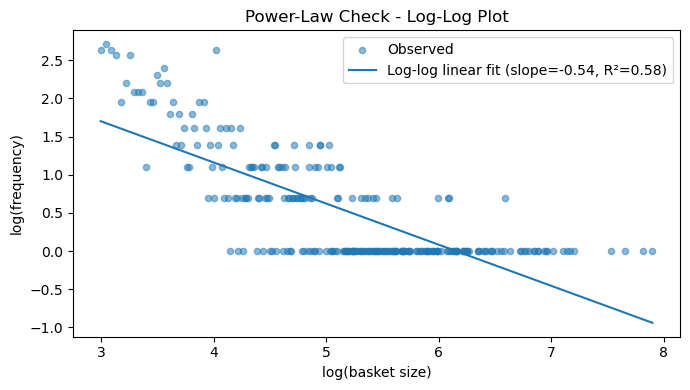

,Metric,Value
0,Slope,-0.54
1,R²,0.58
2,P-value,0.00


In [81]:
# Count how many users have each basket size
basket_frequency = basket_sizes.value_counts().sort_index()

# Apply log transformation to basket sizes and frequencies
log_sizes = np.log(basket_frequency.index)
log_counts = np.log(basket_frequency.values)

# Fit a linear regression in log-log space
slope, intercept, r_value, p_value, _ = stats.linregress(log_sizes, log_counts)

# Plot observed points and fitted line
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(
    log_sizes,
    log_counts,
    alpha=0.5,
    s=20,
    label="Observed"
)

ax.plot(
    log_sizes,
    intercept + slope * log_sizes,
    label=f"Log-log linear fit (slope={slope:.2f}, R²={r_value**2:.2f})"
)

ax.set_xlabel("log(basket size)")
ax.set_ylabel("log(frequency)")
ax.set_title("Power-Law Check - Log-Log Plot")
ax.legend()

plt.tight_layout()
plt.show()

# Display regression summary
power_law_summary = pd.DataFrame({
    "Metric": ["Slope", "R²", "P-value"],
    "Value": [round(slope, 2), round(r_value**2, 2), round(p_value, 4)]
})

display(power_law_summary)

The results suggest a weak and inconclusive power-law fit. Although the p-value indicates that the log-log relationship is statistically significant, the R² value of 0.58 shows that the linear model explains only part of the variation in the log-log plot. A stronger power-law pattern would normally appear closer to a straight line in this representation.

The slope of -0.54 is also outside the typical range expected for many empirical power-law distributions. Therefore, the basket size distribution should be described as **heavy-tailed** and **power-law-like**, but it does not strictly follow a clean power law.

This result is also affected by the structure of the MovieLens small dataset: every user has at least 20 ratings, which truncates the left tail of the distribution and makes a clean power-law fit less likely.

## 3. Data Transformation

The raw MovieLens tables cannot be directly used by all recommender algorithms. Different methods require different input representations: some models work with explicit rating values, others require binary relevance signals, and content-based methods need numerical representations of movie metadata.

Based on the data understanding stage, three main transformation needs were identified:

1. **Content representation:** movie genres are stored as pipe-separated strings and must be converted into numerical indicator variables.
2. **Binary relevance signal:** for ranking-based evaluation, ratings must be transformed into a positive/non-positive relevance signal.
3. **Explicit rating normalisation:** for rating prediction and collaborative filtering, user rating bias should be handled carefully.

To avoid data leakage, transformations that depend on rating statistics, such as user-mean centering, must be computed using only the training set. Transformations that depend only on item metadata, such as genre encoding, can be performed before the train/validation/test split.

### 3.1 Genre Multi-Hot Encoding

The `genres` column stores each movie's genres as a pipe-separated string, for example `Action|Adventure|Sci-Fi`. Since machine learning models cannot directly use this raw text representation, the genres are converted into a multi-hot encoded matrix, where each genre becomes a binary feature.

This transformation is useful for content-based and semantic recommendation components, because it allows movies to be compared using metadata rather than only user interactions.

In [82]:
# Convert pipe-separated genres into binary indicator columns
genres_encoded = movies["genres"].str.get_dummies(sep="|")

# Combine movie identifiers, titles and encoded genres
movies_content = pd.concat(
    [movies[["movieId", "title"]], genres_encoded],
    axis=1
)

print("--- Content Preprocessing Complete ---")
print(f"Genre matrix shape: {movies_content.shape}")
print(f"Number of genre features: {genres_encoded.shape[1]}")

display(movies_content.head())

--- Content Preprocessing Complete ---
Genre matrix shape: (9742, 22)
Number of genre features: 20


,movieId,title,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### 3.2 Binary Relevance Signal

Some recommendation methods, such as Association Rules, BPR and Neural Collaborative Filtering in a ranking setting, require a binary relevance signal instead of a continuous rating.

Following the definition used in the Business Understanding and Data Understanding sections, a movie is considered relevant when the user rated it with `rating >= 4`. Ratings below 4 are treated as non-relevant for the binary evaluation scenario.

This avoids treating low ratings as positive preferences during evaluation, while still allowing the existence of a rating to indicate that the user interacted with the movie.

In [83]:
# A movie is considered relevant if the user rated it with 4.0 or higher
POSITIVE_THRESHOLD = 4.0

ratings["liked"] = (ratings["rating"] >= POSITIVE_THRESHOLD).astype(int)

# Count positive and non-positive interactions
n_pos = ratings["liked"].sum()
n_neg = len(ratings) - n_pos

binary_summary = pd.DataFrame({
    "Class": ["Relevant / liked", "Non-relevant / not liked"],
    "Condition": [f"rating >= {POSITIVE_THRESHOLD}", f"rating < {POSITIVE_THRESHOLD}"],
    "Count": [n_pos, n_neg],
    "Percentage": [
        f"{100 * n_pos / len(ratings):.1f}%",
        f"{100 * n_neg / len(ratings):.1f}%"
    ]
})

display(binary_summary)

,Class,Condition,Count,Percentage
0,Relevant / liked,rating >= 4.0,48580,48.2%
1,Non-relevant / not liked,rating < 4.0,52256,51.8%


The binary transformation creates the target variable `liked`, which will be used in the ranking-based recommendation setting. With the threshold `rating >= 4`, the positive class represents movies that users rated highly, while lower ratings are not treated as relevant items for evaluation.

This binary representation is especially important for Precision@3 and Recall@3, because these metrics require a clear definition of what counts as a relevant recommendation.

### 3.3 Train / Validation / Test Split

Before modelling, the data is split into training, validation and test sets. The split is performed separately for each user, so that every user remains represented in all three sets.

The training set is used to learn model parameters, the validation set is used for tuning and comparing configurations, and the test set is reserved for final evaluation. This avoids evaluating models on the same interactions used during training.

The split used here is approximately 80% training, 10% validation and 10% test per user.

In [84]:
def split_user_interactions(user_df, val_size=0.1, test_size=0.1, random_state=RANDOM_STATE):
    """
    Split one user's interactions into train, validation and test sets.

    The split is done per user to ensure that each user remains represented
    in all three sets whenever possible.
    """
    n_records = len(user_df)

    # Ensure at least one record in validation and test for each user
    n_test = max(1, int(round(n_records * test_size)))
    n_val = max(1, int(round(n_records * val_size)))

    # Shuffle this user's interactions
    shuffled_idx = user_df.sample(frac=1, random_state=random_state).index

    test_idx = shuffled_idx[:n_test]
    val_idx = shuffled_idx[n_test:n_test + n_val]
    train_idx = shuffled_idx[n_test + n_val:]

    return train_idx, val_idx, test_idx


# Store global indices for each split
train_indices, val_indices, test_indices = [], [], []

# Apply the split user by user
for _, user_group in ratings.groupby("userId"):
    tr, v, te = split_user_interactions(
        user_group,
        val_size=0.1,
        test_size=0.1,
        random_state=RANDOM_STATE
    )
    train_indices.extend(tr)
    val_indices.extend(v)
    test_indices.extend(te)

# Create the three datasets
train_set = ratings.loc[train_indices].copy()
val_set = ratings.loc[val_indices].copy()
test_set = ratings.loc[test_indices].copy()

# Summarise the split
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Records": [len(train_set), len(val_set), len(test_set)],
    "Percentage": [
        f"{100 * len(train_set) / len(ratings):.1f}%",
        f"{100 * len(val_set) / len(ratings):.1f}%",
        f"{100 * len(test_set) / len(ratings):.1f}%"
    ],
    "Users": [
        train_set["userId"].nunique(),
        val_set["userId"].nunique(),
        test_set["userId"].nunique()
    ],
    "Relevant items": [
        train_set["liked"].sum(),
        val_set["liked"].sum(),
        test_set["liked"].sum()
    ]
})

display(split_summary)

,Split,Records,Percentage,Users,Relevant items
0,Train,80650,80.0%,610,38877
1,Validation,10093,10.0%,610,4832
2,Test,10093,10.0%,610,4871


The split preserves all users across the training, validation and test sets. This is important for recommender systems because evaluation is performed at user level: each user needs a training history and held-out interactions against which recommendations can be evaluated.

The validation set will be used to compare and tune model configurations, while the test set should only be used for the final evaluation of the selected approaches.

### 3.4 User-Mean Centering Using Training Data Only

For explicit rating prediction and collaborative filtering, user rating bias should be considered. Some users give high ratings very easily, while others are more strict. User-mean centering removes this individual bias by subtracting each user's average rating.

To avoid data leakage, user means are computed using only the training set. The same training-based user means are then applied to the validation and test sets.

In [85]:
# Compute user means using only the training set
user_train_means = train_set.groupby("userId")["rating"].mean()

# Global training mean as fallback for any unexpected missing user
global_train_mean = train_set["rating"].mean()

def add_centered_rating(df, user_means, global_mean):
    """
    Add training-based user means and centred ratings to a dataframe.
    """
    df = df.copy()
    df["user_mean_train"] = df["userId"].map(user_means).fillna(global_mean)
    df["rating_centered"] = df["rating"] - df["user_mean_train"]
    return df

# Apply the training-based centering to all splits
train_set = add_centered_rating(train_set, user_train_means, global_train_mean)
val_set = add_centered_rating(val_set, user_train_means, global_train_mean)
test_set = add_centered_rating(test_set, user_train_means, global_train_mean)

# Inspect the transformed training set
display(train_set.head())

,userId,movieId,rating,timestamp,liked,user_mean_train,rating_centered
150,1,2366,4.0,964982462,1,4.370968,-0.370968
55,1,1031,5.0,964982653,1,4.370968,0.629032
230,1,4006,4.0,964982903,1,4.370968,-0.370968
69,1,1197,5.0,964981872,1,4.370968,0.629032
168,1,2596,5.0,964981144,1,4.370968,0.629032


User-mean centering creates the variable `rating_centered`, which represents how much a user's rating deviates from that user's typical rating behaviour. Positive centred values indicate that the user rated a movie above their personal average, while negative values indicate a rating below their personal average.

Because the user averages were computed only from the training set, the validation and test interactions remain unseen during this transformation. This avoids data leakage and makes the later evaluation more reliable.

### 3.5 Transformation Summary

At the end of the transformation stage, the dataset contains the following additional representations:

- `liked`: binary relevance signal used for ranking-based recommendation and Precision@3 / Recall@3 evaluation;
- `rating_centered`: user-mean centred rating used for explicit preference modelling;
- `movies_content`: multi-hot encoded movie metadata based on genres;
- `train_set`, `val_set` and `test_set`: user-level splits for model training, validation and final evaluation.

These transformations bridge the gap between the raw MovieLens tables and the input formats required by the recommendation algorithms used in the modelling stage.

In [86]:
transformation_summary = pd.DataFrame({
    "Object / Column": [
        "liked",
        "rating_centered",
        "movies_content",
        "train_set",
        "val_set",
        "test_set"
    ],
    "Purpose": [
        "Binary relevance target for ranking-based evaluation",
        "Centred explicit rating controlling for user bias",
        "Genre-based movie metadata representation",
        "Training interactions",
        "Validation interactions",
        "Final test interactions"
    ],
    "Used by": [
        "AR, BPR, NCF, Precision@3 / Recall@3",
        "CF, Matrix Factorization",
        "Content-based and RAG-oriented components",
        "All models",
        "Hyperparameter tuning and model comparison",
        "Final evaluation"
    ]
})

display(transformation_summary)

,Object / Column,Purpose,Used by
0,liked,Binary relevance target for ranking-based eval...,"AR, BPR, NCF, Precision@3 / Recall@3"
1,rating_centered,Centred explicit rating controlling for user bias,"CF, Matrix Factorization"
2,movies_content,Genre-based movie metadata representation,Content-based and RAG-oriented components
3,train_set,Training interactions,All models
4,val_set,Validation interactions,Hyperparameter tuning and model comparison
5,test_set,Final test interactions,Final evaluation


## 4. Modeling — Probing on 20% User Sample

Before applying the recommendation algorithms to the full MovieLens dataset, we first create a smaller probing sample with approximately 20% of the users. This follows the assignment requirement and allows the modelling pipeline to be tested more quickly before scaling the experiments to the full dataset.

The goal of this stage is not yet to obtain the final best model, but to check whether the different recommendation approaches work correctly, compare their initial behaviour, tune key hyperparameters and identify promising configurations.

The methods tested in this probing stage are:

- Popularity baseline;
- Association Rules;
- Collaborative Filtering;
- Matrix Factorization;
- BPR;
- Neural Collaborative Filtering.

All models are evaluated with **Precision@3** and **Recall@3**, using the binary relevance definition introduced earlier: a movie is considered relevant when `rating >= 4`.

### 4.1 Create and Validate 20% User Sample

The probing sample is created by randomly selecting 20% of the users and keeping all their ratings. Sampling users rather than individual ratings preserves complete user profiles, which is important because recommendations are evaluated at user level.

Since user activity is highly uneven, the percentage of ratings in the sample may not be exactly 20%. Therefore, we compare the sample with the full dataset in terms of rating distribution and basket size.

In [87]:
# Select 20% of users
all_users = ratings["userId"].unique()

sample_users = pd.Series(all_users).sample(
    frac=0.20,
    random_state=RANDOM_STATE
).values

ratings_sample = ratings[ratings["userId"].isin(sample_users)].copy()

# Summary of full dataset vs sample
sample_summary = pd.DataFrame({
    "Dataset": ["Full dataset", "20% user sample"],
    "Users": [
        ratings["userId"].nunique(),
        ratings_sample["userId"].nunique()
    ],
    "Ratings": [
        len(ratings),
        len(ratings_sample)
    ],
    "Movies rated": [
        ratings["movieId"].nunique(),
        ratings_sample["movieId"].nunique()
    ],
    "Mean rating": [
        round(ratings["rating"].mean(), 2),
        round(ratings_sample["rating"].mean(), 2)
    ],
    "Median rating": [
        ratings["rating"].median(),
        ratings_sample["rating"].median()
    ],
    "Relevant ratings": [
        ratings["liked"].sum(),
        ratings_sample["liked"].sum()
    ]
})

display(sample_summary)

,Dataset,Users,Ratings,Movies rated,Mean rating,Median rating,Relevant ratings
0,Full dataset,610,100836,9724,3.50,3.5,48580
1,20% user sample,122,27659,6424,3.44,3.5,12374


,rating,full_dataset,sample_20_users
0,0.5,0.013586,0.012871
1,1.0,0.027877,0.024007
2,1.5,0.017762,0.026393
3,2.0,0.074884,0.070031
4,2.5,0.055040,0.078275
5,3.0,0.198808,0.188112
6,3.5,0.130271,0.152934
7,4.0,0.265957,0.256336
8,4.5,0.084801,0.088253
9,5.0,0.131015,0.102788


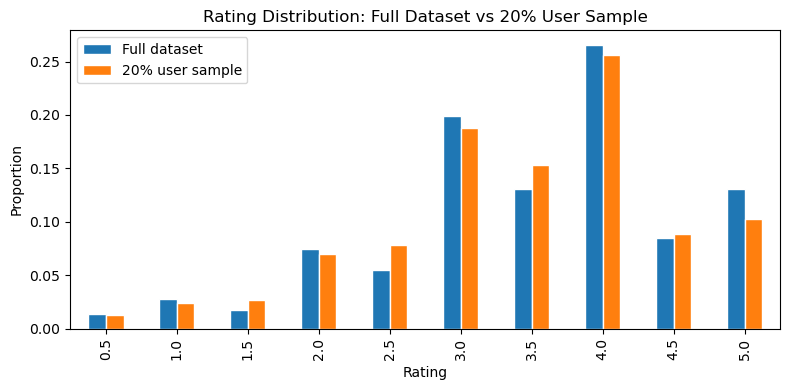

In [88]:
# Compare rating distributions

full_rating_dist = ratings["rating"].value_counts(normalize=True).sort_index()
sample_rating_dist = ratings_sample["rating"].value_counts(normalize=True).sort_index()

rating_comparison = pd.DataFrame({
    "rating": full_rating_dist.index,
    "full_dataset": full_rating_dist.values,
    "sample_20_users": sample_rating_dist.reindex(full_rating_dist.index, fill_value=0).values
})

display(rating_comparison)

fig, ax = plt.subplots(figsize=(8, 4))

rating_comparison.plot(
    x="rating",
    y=["full_dataset", "sample_20_users"],
    kind="bar",
    ax=ax,
    edgecolor="white"
)

ax.set_xlabel("Rating")
ax.set_ylabel("Proportion")
ax.set_title("Rating Distribution: Full Dataset vs 20% User Sample")
ax.legend(["Full dataset", "20% user sample"])

plt.tight_layout()
plt.show()

,Metric,Full dataset,20% user sample
0,Minimum ratings per user,20.0,20.0
1,Maximum ratings per user,2698.0,2478.0
2,Mean ratings per user,165.3,226.7
3,Median ratings per user,70.0,98.0
4,90th percentile,400.0,526.0
5,95th percentile,610.0,860.0


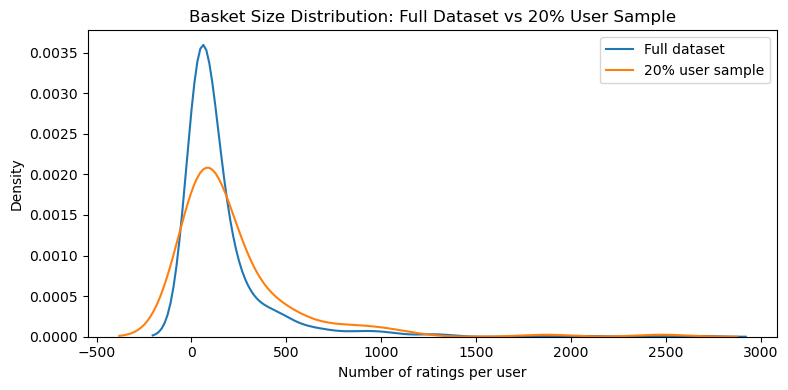

In [89]:
# Compare basket size distributions

basket_full = ratings.groupby("userId")["movieId"].count()
basket_sample = ratings_sample.groupby("userId")["movieId"].count()

basket_comparison = pd.DataFrame({
    "Metric": [
        "Minimum ratings per user",
        "Maximum ratings per user",
        "Mean ratings per user",
        "Median ratings per user",
        "90th percentile",
        "95th percentile"
    ],
    "Full dataset": [
        int(basket_full.min()),
        int(basket_full.max()),
        round(basket_full.mean(), 1),
        int(basket_full.median()),
        int(np.percentile(basket_full, 90)),
        int(np.percentile(basket_full, 95))
    ],
    "20% user sample": [
        int(basket_sample.min()),
        int(basket_sample.max()),
        round(basket_sample.mean(), 1),
        int(basket_sample.median()),
        int(np.percentile(basket_sample, 90)),
        int(np.percentile(basket_sample, 95))
    ]
})

display(basket_comparison)

fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(basket_full, label="Full dataset", ax=ax)
sns.kdeplot(basket_sample, label="20% user sample", ax=ax)

ax.set_xlabel("Number of ratings per user")
ax.set_ylabel("Density")
ax.set_title("Basket Size Distribution: Full Dataset vs 20% User Sample")
ax.legend()

plt.tight_layout()
plt.show()

The 20% user sample preserves the main characteristics of the full dataset. The rating distribution should remain close to the original distribution, with the same positive skew observed earlier. The basket size distribution should also preserve the same general right-skewed pattern, although some differences are expected because the sample contains fewer users.

This sample is therefore suitable for initial probing experiments, where the goal is to test the recommendation pipeline before scaling to the full dataset.

### 4.2 Train / Validation Split for the 20% User Sample

For the probing stage, the 20% user sample is split into training and validation sets. The split is performed separately for each user, so that every sampled user has both a training history and held-out interactions for validation.

The validation set will be used to compare initial model configurations.

In [90]:
def split_user_train_val(user_df, val_size=0.2, random_state=RANDOM_STATE):
    """
    Split one user's interactions into train and validation sets.
    """
    n_records = len(user_df)

    # Ensure at least one validation interaction per user
    n_val = max(1, int(round(n_records * val_size)))

    shuffled_idx = user_df.sample(frac=1, random_state=random_state).index

    val_idx = shuffled_idx[:n_val]
    train_idx = shuffled_idx[n_val:]

    return train_idx, val_idx


sample_train_indices, sample_val_indices = [], []

for _, user_group in ratings_sample.groupby("userId"):
    tr, v = split_user_train_val(
        user_group,
        val_size=0.2,
        random_state=RANDOM_STATE
    )
    sample_train_indices.extend(tr)
    sample_val_indices.extend(v)

sample_train = ratings_sample.loc[sample_train_indices].copy()
sample_val = ratings_sample.loc[sample_val_indices].copy()

sample_split_summary = pd.DataFrame({
    "Split": ["Sample train", "Sample validation"],
    "Records": [len(sample_train), len(sample_val)],
    "Percentage": [
        f"{100 * len(sample_train) / len(ratings_sample):.1f}%",
        f"{100 * len(sample_val) / len(ratings_sample):.1f}%"
    ],
    "Users": [
        sample_train["userId"].nunique(),
        sample_val["userId"].nunique()
    ],
    "Relevant items": [
        sample_train["liked"].sum(),
        sample_val["liked"].sum()
    ]
})

display(sample_split_summary)

,Split,Records,Percentage,Users,Relevant items
0,Sample train,22130,80.0%,122,9902
1,Sample validation,5529,20.0%,122,2472


The sample is now divided into training and validation sets. Each sampled user remains represented in both sets, which allows each model to learn from part of the user's history and be evaluated on held-out interactions.

This validation split will be used for the probing experiments.

### 4.3 Evaluation Functions: Precision@3 and Recall@3

The assignment requires Precision@3 and Recall@3 as the main evaluation metrics. These metrics evaluate whether the top-3 recommended movies contain relevant held-out items.

For each user, relevant items are defined as validation movies with `liked = 1`, meaning that the user rated them with `rating >= 4`. Recommended movies already seen in the training set are removed from the candidate list.

In [91]:
def precision_at_k(recommended_items, relevant_items, k=3):
    """
    Compute Precision@K for a single user.
    """
    recommended_k = recommended_items[:k]

    if len(recommended_k) == 0:
        return 0.0

    hits = len(set(recommended_k) & set(relevant_items))
    return hits / k


def recall_at_k(recommended_items, relevant_items, k=3):
    """
    Compute Recall@K for a single user.
    """
    recommended_k = recommended_items[:k]

    if len(relevant_items) == 0:
        return np.nan

    hits = len(set(recommended_k) & set(relevant_items))
    return hits / len(relevant_items)


def evaluate_recommendations_at_k(recommendations, train_df, eval_df, k=3):
    """
    Evaluate recommendation lists using Precision@K and Recall@K.

    recommendations: dictionary {userId: [movieId1, movieId2, ...]}
    train_df: training interactions
    eval_df: validation or test interactions
    k: recommendation list length
    """
    precision_scores = []
    recall_scores = []

    relevant_by_user = (
        eval_df[eval_df["liked"] == 1]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    seen_by_user = (
        train_df
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    for user_id, relevant_items in relevant_by_user.items():
        if user_id not in recommendations:
            continue

        recommended_items = recommendations[user_id]

        # Remove movies already seen in training
        seen_items = seen_by_user.get(user_id, set())
        recommended_items = [
            item for item in recommended_items
            if item not in seen_items
        ]

        precision_scores.append(
            precision_at_k(recommended_items, relevant_items, k=k)
        )
        recall_scores.append(
            recall_at_k(recommended_items, relevant_items, k=k)
        )

    return {
        f"Precision@{k}": np.nanmean(precision_scores),
        f"Recall@{k}": np.nanmean(recall_scores),
        "Evaluated users": len(precision_scores)
    }

In [92]:
# Quick check

toy_recommendations = {
    1: [10, 20, 30],
    2: [40, 50, 60]
}

toy_train = pd.DataFrame({
    "userId": [1, 2],
    "movieId": [99, 88],
    "liked": [1, 1]
})

toy_eval = pd.DataFrame({
    "userId": [1, 1, 2],
    "movieId": [10, 40, 70],
    "liked": [1, 1, 1]
})

evaluate_recommendations_at_k(
    toy_recommendations,
    toy_train,
    toy_eval,
    k=3
)

{'Precision@3': np.float64(0.16666666666666666),
 'Recall@3': np.float64(0.25),
 'Evaluated users': 2}

The evaluation functions compute Precision@3 and Recall@3 at user level and then average the results across users with at least one relevant item in the validation set.

The same functions will be reused for all recommendation methods, ensuring a fair comparison.

### 4.4 Popularity Baseline

Before testing more complex recommendation algorithms, we define a simple popularity-based baseline. This model recommends the globally most liked movies in the training set to every user, excluding movies the user has already rated.

This baseline is important because it provides a minimum reference point: more complex models should ideally outperform a simple popularity ranking.

In [93]:
# Rank movies by the number of positive interactions in the training set
popular_movies = (
    sample_train[sample_train["liked"] == 1]
    .groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

def recommend_popular(user_id, train_df, popular_items, n=20):
    """
    Recommend globally popular movies not yet seen by the user.
    """
    seen_items = set(train_df[train_df["userId"] == user_id]["movieId"])
    recs = [item for item in popular_items if item not in seen_items]
    return recs[:n]


popularity_recommendations = {
    user_id: recommend_popular(user_id, sample_train, popular_movies, n=20)
    for user_id in sample_val["userId"].unique()
}

popularity_results = evaluate_recommendations_at_k(
    popularity_recommendations,
    sample_train,
    sample_val,
    k=3
)

popularity_results_df = pd.DataFrame([{
    "Model": "Popularity baseline",
    **popularity_results
}])

display(popularity_results_df)

,Model,Precision@3,Recall@3,Evaluated users
0,Popularity baseline,0.203857,0.036804,121


The popularity baseline recommends the same globally popular movies to all users, after removing movies already seen in the training set. Its performance is expected to be limited because it is not personalised, but it is a useful reference for evaluating whether more complex models add value.

### 4.5 Association Rules

Association Rule Mining treats recommendation as a market-basket problem. Instead of predicting a rating, it searches for patterns of the form: users who liked movie A also tend to like movie B.

This method requires binary transactions, so it uses only the `liked` variable. In this notebook, a movie is included in a user's transaction basket when `rating >= 4`.

Association Rules are useful as an interpretable recommendation method, but they may favour popular movies and struggle with sparse user histories.

In [94]:
from mlxtend.frequent_patterns import apriori, association_rules

# Use only liked movies from the sample training set
ar_train = sample_train[sample_train["liked"] == 1].copy()

# Safer support threshold for sparse data
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.20

# Keep only movies liked by at least MIN_SUPPORT proportion of users
min_user_count = int(np.ceil(MIN_SUPPORT * ar_train["userId"].nunique()))

frequent_movies = (
    ar_train.groupby("movieId")["userId"]
    .nunique()
    .loc[lambda x: x >= min_user_count]
    .index
)

ar_train_filtered = ar_train[ar_train["movieId"].isin(frequent_movies)].copy()

print(f"Original liked movies: {ar_train['movieId'].nunique()}")
print(f"Filtered liked movies: {ar_train_filtered['movieId'].nunique()}")
print(f"Minimum users per movie: {min_user_count}")

# Build user-item basket
basket_matrix = (
    ar_train_filtered
    .assign(value=1)
    .pivot_table(
        index="userId",
        columns="movieId",
        values="value",
        fill_value=0
    )
)

basket_matrix_bool = basket_matrix.astype(bool)

print(f"Basket matrix shape after filtering: {basket_matrix_bool.shape}")

# Mine frequent itemsets
frequent_itemsets = apriori(
    basket_matrix_bool,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=2,
    low_memory=True
)

print(f"Number of frequent itemsets: {len(frequent_itemsets)}")

# Generate association rules
if len(frequent_itemsets) > 0:
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=MIN_CONFIDENCE
    )

    rules = rules.sort_values(
        by=["confidence", "lift"],
        ascending=False
    )

    print(f"Number of association rules: {len(rules)}")
    display(rules.head(10))

else:
    rules = pd.DataFrame()
    print("No frequent itemsets found. Try lowering MIN_SUPPORT.")

Original liked movies: 3090
Filtered liked movies: 372
Minimum users per movie: 7
Basket matrix shape after filtering: (121, 372)
Number of frequent itemsets: 4380
Number of association rules: 7709


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
7246,frozenset({5903}),frozenset({7438}),0.057851,0.165289,0.057851,1.0,6.050000,1.0,0.048289,inf,0.885965,0.350000,1.0,0.675000
6817,frozenset({4299}),frozenset({4963}),0.057851,0.181818,0.057851,1.0,5.500000,1.0,0.047333,inf,0.868421,0.318182,1.0,0.659091
4564,frozenset({5956}),frozenset({1221}),0.057851,0.190083,0.057851,1.0,5.260870,1.0,0.046855,inf,0.859649,0.304348,1.0,0.652174
7063,frozenset({8873}),frozenset({4973}),0.057851,0.190083,0.057851,1.0,5.260870,1.0,0.046855,inf,0.859649,0.304348,1.0,0.652174
7525,frozenset({8360}),frozenset({8961}),0.066116,0.190083,0.066116,1.0,5.260870,1.0,0.053548,inf,0.867257,0.347826,1.0,0.673913
843,frozenset({367}),frozenset({110}),0.066116,0.223140,0.066116,1.0,4.481481,1.0,0.051363,inf,0.831858,0.296296,1.0,0.648148
3455,frozenset({5956}),frozenset({1089}),0.057851,0.223140,0.057851,1.0,4.481481,1.0,0.044942,inf,0.824561,0.259259,1.0,0.629630
2854,frozenset({1266}),frozenset({858}),0.057851,0.239669,0.057851,1.0,4.172414,1.0,0.043986,inf,0.807018,0.241379,1.0,0.620690
5301,frozenset({1729}),frozenset({4226}),0.066116,0.247934,0.066116,1.0,4.033333,1.0,0.049723,inf,0.805310,0.266667,1.0,0.633333
6756,frozenset({5956}),frozenset({4226}),0.057851,0.247934,0.057851,1.0,4.033333,1.0,0.043508,inf,0.798246,0.233333,1.0,0.616667


In [95]:
# Evaluate Association Rules
def precision_at_k(recommended_items, relevant_items, k=3):
    recommended_k = recommended_items[:k]

    if len(recommended_k) == 0:
        return 0.0

    hits = len(set(recommended_k) & set(relevant_items))
    return hits / k


def recall_at_k(recommended_items, relevant_items, k=3):
    recommended_k = recommended_items[:k]

    if len(relevant_items) == 0:
        return np.nan

    hits = len(set(recommended_k) & set(relevant_items))
    return hits / len(relevant_items)


def evaluate_recommendations_at_k(recommendations, train_df, eval_df, k=3):
    precision_scores = []
    recall_scores = []

    relevant_by_user = (
        eval_df[eval_df["liked"] == 1]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    seen_by_user = (
        train_df
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    for user_id, relevant_items in relevant_by_user.items():
        if user_id not in recommendations:
            continue

        recommended_items = recommendations[user_id]

        seen_items = seen_by_user.get(user_id, set())
        recommended_items = [
            item for item in recommended_items
            if item not in seen_items
        ]

        precision_scores.append(
            precision_at_k(recommended_items, relevant_items, k=k)
        )
        recall_scores.append(
            recall_at_k(recommended_items, relevant_items, k=k)
        )

    return {
        f"Precision@{k}": np.nanmean(precision_scores),
        f"Recall@{k}": np.nanmean(recall_scores),
        "Evaluated users": len(precision_scores)
    }


def recommend_from_association_rules(user_id, train_df, rules_df, n=20):
    if rules_df.empty:
        return []

    user_liked_items = set(
        train_df[
            (train_df["userId"] == user_id) &
            (train_df["liked"] == 1)
        ]["movieId"]
    )

    user_seen_items = set(
        train_df[train_df["userId"] == user_id]["movieId"]
    )

    candidate_scores = {}

    for _, rule in rules_df.iterrows():
        antecedents = set(rule["antecedents"])
        consequents = set(rule["consequents"])

        if antecedents.issubset(user_liked_items):
            for item in consequents:
                if item not in user_seen_items:
                    score = rule["confidence"] * rule["lift"]
                    candidate_scores[item] = max(
                        candidate_scores.get(item, 0),
                        score
                    )

    ranked_items = sorted(
        candidate_scores,
        key=candidate_scores.get,
        reverse=True
    )

    return ranked_items[:n]


ar_recommendations = {
    user_id: recommend_from_association_rules(
        user_id,
        sample_train,
        rules,
        n=20
    )
    for user_id in sample_val["userId"].unique()
}

ar_results = evaluate_recommendations_at_k(
    ar_recommendations,
    sample_train,
    sample_val,
    k=3
)

ar_results_df = pd.DataFrame([{
    "Model": "Association Rules",
    "min_support": MIN_SUPPORT,
    "min_confidence": MIN_CONFIDENCE,
    **ar_results
}])

display(ar_results_df)

,Model,min_support,min_confidence,Precision@3,Recall@3,Evaluated users
0,Association Rules,0.05,0.2,0.132231,0.034991,121


The Association Rules model achieved a Precision@3 of 0.132 and a Recall@3 of 0.035. Although the method generated a large number of rules, its performance was lower than the popularity baseline in terms of Precision@3 and very similar in terms of Recall@3.

This suggests that, in this sparse probing sample, simple co-occurrence rules are not sufficient to outperform a strong popularity-based baseline. The method remains useful because it is interpretable, but its recommendations may still be biased towards frequent movie pairs and may not capture personalised preferences as effectively as collaborative filtering or matrix factorisation methods.

### 4.6 Collaborative Filtering

Collaborative Filtering recommends items based on similarities in user behaviour. The central assumption is that users who liked similar movies in the past may also like similar movies in the future.

In this probing stage, we implement a user-based collaborative filtering approach using the binary relevance signal `liked`. A user-item matrix is created from the training set, where each row represents a user and each column represents a movie. Cosine similarity is then computed between users.

For each target user, the system finds the most similar users and recommends movies liked by those neighbours, excluding movies already seen by the target user in the training set.



In [96]:
# Collaborative Filtering — User-Based CF
from sklearn.metrics.pairwise import cosine_similarity

def build_user_based_cf_recommendations(train_df, eval_users, n_neighbors=20, n_recommendations=20):
    """
    Build user-based collaborative filtering recommendations.

    The model:
    1. Creates a user-item matrix using the binary 'liked' signal.
    2. Computes cosine similarity between users.
    3. Scores unseen movies using the preferences of similar users.
    4. Returns the top-N unseen movies for each evaluation user.
    """

    # Create user-item matrix with binary liked values
    user_item_matrix = (
        train_df
        .pivot_table(
            index="userId",
            columns="movieId",
            values="liked",
            fill_value=0
        )
    )

    users = user_item_matrix.index.to_list()
    movies_cf = user_item_matrix.columns.to_list()

    user_to_idx = {user_id: idx for idx, user_id in enumerate(users)}

    # Compute user-user cosine similarity
    user_similarity = cosine_similarity(user_item_matrix.values)

    recommendations = {}

    for user_id in eval_users:
        if user_id not in user_to_idx:
            recommendations[user_id] = []
            continue

        user_idx = user_to_idx[user_id]

        # Similarities between this user and all others
        similarities = user_similarity[user_idx].copy()

        # Remove self-similarity
        similarities[user_idx] = -1

        # Select top neighbours
        neighbour_indices = np.argsort(similarities)[::-1][:n_neighbors]
        neighbour_similarities = similarities[neighbour_indices]

        # If all similarities are zero or negative, return no personalised recommendations
        if np.sum(neighbour_similarities > 0) == 0:
            recommendations[user_id] = []
            continue

        # Score items based on neighbour preferences weighted by similarity
        neighbour_matrix = user_item_matrix.values[neighbour_indices]
        item_scores = np.dot(neighbour_similarities, neighbour_matrix)

        # Remove movies already seen by the target user
        seen_items = set(train_df[train_df["userId"] == user_id]["movieId"])

        candidate_scores = {
            movie_id: score
            for movie_id, score in zip(movies_cf, item_scores)
            if movie_id not in seen_items and score > 0
        }

        ranked_items = sorted(
            candidate_scores,
            key=candidate_scores.get,
            reverse=True
        )

        recommendations[user_id] = ranked_items[:n_recommendations]

    return recommendations


# Generate recommendations for validation users
cf_recommendations = build_user_based_cf_recommendations(
    train_df=sample_train,
    eval_users=sample_val["userId"].unique(),
    n_neighbors=20,
    n_recommendations=20
)

# Evaluate CF
cf_results = evaluate_recommendations_at_k(
    cf_recommendations,
    sample_train,
    sample_val,
    k=3
)

cf_results_df = pd.DataFrame([{
    "Model": "User-based Collaborative Filtering",
    "n_neighbors": 20,
    **cf_results
}])

display(cf_results_df)

,Model,n_neighbors,Precision@3,Recall@3,Evaluated users
0,User-based Collaborative Filtering,20,0.280992,0.079953,121


The user-based Collaborative Filtering model achieved a Precision@3 of 0.281 and a Recall@3 of 0.080 with 20 neighbours. This is a clear improvement over both the popularity baseline and Association Rules.

The result suggests that user similarity contains useful information for recommendation in this dataset. Unlike the popularity baseline, which recommends the same items to all users, Collaborative Filtering adapts recommendations to each user's observed preferences. This makes it more effective for producing relevant top-3 recommendations in the probing sample.

#### 4.6.1 Hyperparameter Tuning: Number of Neighbours

The number of neighbours controls how many similar users contribute to each recommendation. A small number of neighbours may produce more specific recommendations but can be unstable. A larger number may be more robust, but can dilute personalisation by including less similar users.

We test several values of `n_neighbors` and compare the resulting Precision@3 and Recall@3.

In [97]:
# Hyperparameter Tuning — Number of Neighbours
neighbor_values = [5, 10, 20, 30, 50]

cf_tuning_results = []

for n_neighbors in neighbor_values:
    cf_recommendations = build_user_based_cf_recommendations(
        train_df=sample_train,
        eval_users=sample_val["userId"].unique(),
        n_neighbors=n_neighbors,
        n_recommendations=20
    )

    results = evaluate_recommendations_at_k(
        cf_recommendations,
        sample_train,
        sample_val,
        k=3
    )

    cf_tuning_results.append({
        "Model": "User-based CF",
        "n_neighbors": n_neighbors,
        **results
    })

cf_tuning_df = pd.DataFrame(cf_tuning_results)

display(cf_tuning_df)

,Model,n_neighbors,Precision@3,Recall@3,Evaluated users
0,User-based CF,5,0.228650,0.059588,121
1,User-based CF,10,0.258953,0.072577,121
2,User-based CF,20,0.280992,0.079953,121
3,User-based CF,30,0.275482,0.070578,121
4,User-based CF,50,0.272727,0.068374,121


The tuning results show that user-based Collaborative Filtering performs best with 20 neighbours. This configuration achieved the highest Precision@3 and Recall@3 in the probing sample.

Using too few neighbours may provide insufficient information, while using too many neighbours can dilute personalisation by including less similar users. Therefore, `n_neighbors = 20` is selected as the best Collaborative Filtering configuration for the probing stage.

In [98]:
# Store Best Collaborative Filtering Result
best_cf_result = cf_tuning_df.sort_values(
    by="Precision@3",
    ascending=False
).iloc[0]

best_cf_results_df = pd.DataFrame([best_cf_result])

display(best_cf_results_df)

,Model,n_neighbors,Precision@3,Recall@3,Evaluated users
2,User-based CF,20,0.280992,0.079953,121


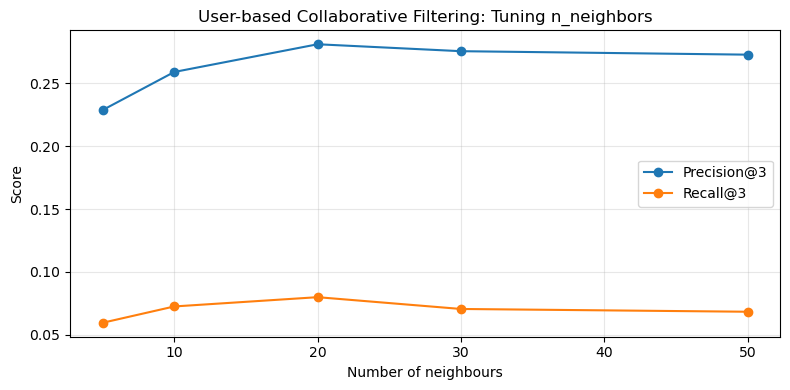

In [99]:
# Plot CF Hyperparameter Tuning Results
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    cf_tuning_df["n_neighbors"],
    cf_tuning_df["Precision@3"],
    marker="o",
    label="Precision@3"
)

ax.plot(
    cf_tuning_df["n_neighbors"],
    cf_tuning_df["Recall@3"],
    marker="o",
    label="Recall@3"
)

ax.set_xlabel("Number of neighbours")
ax.set_ylabel("Score")
ax.set_title("User-based Collaborative Filtering: Tuning n_neighbors")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The plot confirms that the best Collaborative Filtering performance is obtained with `n_neighbors = 20`. Both Precision@3 and Recall@3 increase from 5 to 20 neighbours, suggesting that a moderate number of similar users provides useful collaborative information.

After 20 neighbours, performance decreases slightly. This indicates that adding more neighbours introduces less similar users, which can dilute personalisation. Therefore, `n_neighbors = 20` is selected as the best user-based Collaborative Filtering configuration for the probing stage.

### 4.7 Matrix Factorization

Matrix Factorization represents users and movies in a lower-dimensional latent space. Instead of comparing users directly, as in Collaborative Filtering, this method decomposes the user-item interaction matrix into latent factors that capture hidden preference patterns.

In this probing stage, we use the binary `liked` signal and apply matrix factorization through Truncated SVD. The model learns latent user and item representations from the training set and then scores unseen movies for each validation user.

Movies already seen by the user in the training set are excluded from the recommendation list. The model is evaluated with Precision@3 and Recall@3.

In [100]:
# Matrix Factorization — Initial Model
from sklearn.decomposition import TruncatedSVD

def build_matrix_factorization_recommendations(
    train_df,
    eval_users,
    n_factors=20,
    n_recommendations=20,
    random_state=RANDOM_STATE
):
    """
    Build recommendations using Matrix Factorization with Truncated SVD.

    The model:
    1. Builds a user-item matrix using the binary 'liked' signal.
    2. Factorizes the matrix into latent user and item representations.
    3. Reconstructs preference scores.
    4. Recommends the highest-scoring unseen movies.
    """

    # Create user-item matrix
    user_item_matrix = (
        train_df
        .pivot_table(
            index="userId",
            columns="movieId",
            values="liked",
            fill_value=0
        )
    )

    users = user_item_matrix.index.to_list()
    movies_mf = user_item_matrix.columns.to_list()

    user_to_idx = {user_id: idx for idx, user_id in enumerate(users)}

    # Ensure n_factors is valid for the matrix dimensions
    max_factors = min(user_item_matrix.shape) - 1
    n_factors = min(n_factors, max_factors)

    # Fit Matrix Factorization model
    svd = TruncatedSVD(
        n_components=n_factors,
        random_state=random_state
    )

    user_factors = svd.fit_transform(user_item_matrix.values)
    item_factors = svd.components_

    # Reconstruct approximate user-item preference scores
    predicted_scores = np.dot(user_factors, item_factors)

    recommendations = {}

    for user_id in eval_users:
        if user_id not in user_to_idx:
            recommendations[user_id] = []
            continue

        user_idx = user_to_idx[user_id]

        scores = predicted_scores[user_idx]

        seen_items = set(
            train_df[train_df["userId"] == user_id]["movieId"]
        )

        candidate_scores = {
            movie_id: score
            for movie_id, score in zip(movies_mf, scores)
            if movie_id not in seen_items
        }

        ranked_items = sorted(
            candidate_scores,
            key=candidate_scores.get,
            reverse=True
        )

        recommendations[user_id] = ranked_items[:n_recommendations]

    return recommendations


# Generate recommendations with an initial number of latent factors
mf_recommendations = build_matrix_factorization_recommendations(
    train_df=sample_train,
    eval_users=sample_val["userId"].unique(),
    n_factors=20,
    n_recommendations=20
)

# Evaluate Matrix Factorization
mf_results = evaluate_recommendations_at_k(
    mf_recommendations,
    sample_train,
    sample_val,
    k=3
)

mf_results_df = pd.DataFrame([{
    "Model": "Matrix Factorization",
    "n_factors": 20,
    **mf_results
}])

display(mf_results_df)

,Model,n_factors,Precision@3,Recall@3,Evaluated users
0,Matrix Factorization,20,0.179063,0.043953,121


The initial Matrix Factorization model with 20 latent factors achieved a Precision@3 of 0.179 and a Recall@3 of 0.044. This result is better than Association Rules but lower than the user-based Collaborative Filtering model.

This suggests that, in the probing sample, direct user similarity is currently more effective than the latent representation learned by Truncated SVD. However, this is only the initial configuration, so the number of latent factors should be tuned before drawing a final conclusion.

#### 4.7.2 Hyperparameter Tuning: Number of Latent Factors

The number of latent factors controls the complexity of the Matrix Factorization model. A small number of factors may underfit the data, while too many factors may capture noise and reduce generalisation.

We test several values of `n_factors` and compare the resulting Precision@3 and Recall@3.

In [101]:
# Hyperparameter Tuning — Number of Latent Factors
factor_values = [5, 10, 20, 30, 50]

mf_tuning_results = []

for n_factors in factor_values:
    mf_recommendations = build_matrix_factorization_recommendations(
        train_df=sample_train,
        eval_users=sample_val["userId"].unique(),
        n_factors=n_factors,
        n_recommendations=20
    )

    results = evaluate_recommendations_at_k(
        mf_recommendations,
        sample_train,
        sample_val,
        k=3
    )

    mf_tuning_results.append({
        "Model": "Matrix Factorization",
        "n_factors": n_factors,
        **results
    })

mf_tuning_df = pd.DataFrame(mf_tuning_results)

display(mf_tuning_df)

,Model,n_factors,Precision@3,Recall@3,Evaluated users
0,Matrix Factorization,5,0.203857,0.046871,121
1,Matrix Factorization,10,0.239669,0.056522,121
2,Matrix Factorization,20,0.179063,0.043953,121
3,Matrix Factorization,30,0.187328,0.063262,121
4,Matrix Factorization,50,0.184573,0.070305,121


The tuning results show that Matrix Factorization performs best in terms of Precision@3 with `n_factors = 10`. This configuration achieves a Precision@3 of 0.240 and a Recall@3 of 0.057.

Although the model with 50 latent factors obtains the highest Recall@3, its Precision@3 is lower. Since the assignment focuses on the quality of the top-3 recommendations, `n_factors = 10` is selected as the best Matrix Factorization configuration for the probing stage.

Compared with user-based Collaborative Filtering, Matrix Factorization performs worse in this sample. This suggests that, for the current probing setup, direct user similarity captures user preferences more effectively than the latent factors learned by Truncated SVD.

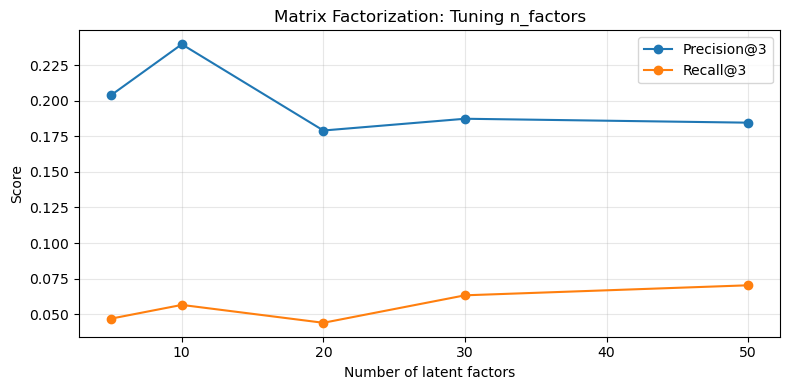

In [102]:
# Plot MF Hyperparameter Tuning Results
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    mf_tuning_df["n_factors"],
    mf_tuning_df["Precision@3"],
    marker="o",
    label="Precision@3"
)

ax.plot(
    mf_tuning_df["n_factors"],
    mf_tuning_df["Recall@3"],
    marker="o",
    label="Recall@3"
)

ax.set_xlabel("Number of latent factors")
ax.set_ylabel("Score")
ax.set_title("Matrix Factorization: Tuning n_factors")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [103]:
# Store Best Matrix Factorization Result
best_mf_result = mf_tuning_df.sort_values(
    by="Precision@3",
    ascending=False
).iloc[0]

best_mf_results_df = pd.DataFrame([best_mf_result])

display(best_mf_results_df)

,Model,n_factors,Precision@3,Recall@3,Evaluated users
1,Matrix Factorization,10,0.239669,0.056522,121


The plot shows that Matrix Factorization reaches its best Precision@3 with `n_factors = 10`. After this point, Precision@3 decreases, suggesting that adding more latent factors does not improve the quality of the top-3 recommendations in this probing sample.

Although Recall@3 increases again for larger numbers of factors, the assignment focuses mainly on the relevance of the top-3 recommendations. Therefore, `n_factors = 10` is selected as the best Matrix Factorization configuration.

### 4.8 Bayesian Personalized Ranking (BPR)

Bayesian Personalized Ranking (BPR) is a pairwise learning-to-rank method designed for implicit feedback recommendation. Instead of predicting exact ratings, BPR learns that, for each user, liked movies should be ranked above unobserved movies.

In this project, positive interactions are defined using the binary variable `liked`, where a movie is considered relevant when `rating >= 4`. For each positive user-movie interaction, BPR samples an unseen movie as a negative example and updates latent user and item factors so that the positive movie receives a higher score.

This approach is aligned with the project objective because the final task is to recommend a ranked top-3 list of movies, evaluated with Precision@3 and Recall@3.

In [104]:
# Evaluation Functions: Precision@3 and Recall@3
def precision_at_k(recommended_items, relevant_items, k=3):
    """
    Precision@K = number of relevant recommended items / K
    """
    recommended_k = recommended_items[:k]

    if len(recommended_k) == 0:
        return 0.0

    hits = len(set(recommended_k) & set(relevant_items))
    return hits / k


def recall_at_k(recommended_items, relevant_items, k=3):
    """
    Recall@K = number of relevant recommended items / total relevant held-out items
    """
    recommended_k = recommended_items[:k]

    if len(relevant_items) == 0:
        return np.nan

    hits = len(set(recommended_k) & set(relevant_items))
    return hits / len(relevant_items)


def evaluate_recommendations_at_k(recommendations, train_df, eval_df, k=3):
    """
    Evaluate top-K recommendations using Precision@K and Recall@K.
    Already-seen training items are removed before evaluation.
    """
    precision_scores = []
    recall_scores = []

    relevant_by_user = (
        eval_df[eval_df["liked"] == 1]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    seen_by_user = (
        train_df
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    for user_id, relevant_items in relevant_by_user.items():
        recommended_items = recommendations.get(user_id, [])

        seen_items = seen_by_user.get(user_id, set())
        recommended_items = [
            item for item in recommended_items
            if item not in seen_items
        ]

        precision_scores.append(
            precision_at_k(recommended_items, relevant_items, k=k)
        )

        recall_scores.append(
            recall_at_k(recommended_items, relevant_items, k=k)
        )

    return {
        f"Precision@{k}": np.nanmean(precision_scores),
        f"Recall@{k}": np.nanmean(recall_scores),
        "Evaluated users": len(precision_scores)
    }

In [105]:
# 4.8.2 Simple BPR Model

class SimpleBPR:
    """
    Simple Bayesian Personalized Ranking model using NumPy.

    Positive items are movies with liked = 1.
    Negative items are sampled from movies the user has not interacted with.
    """

    def __init__(
        self,
        n_factors=20,
        learning_rate=0.05,
        regularization=0.01,
        n_epochs=10,
        random_state=42
    ):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.regularization = regularization
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, train_df):
        rng = np.random.default_rng(self.random_state)

        self.users = sorted(train_df["userId"].unique())
        self.items = sorted(train_df["movieId"].unique())

        self.user_to_idx = {user: idx for idx, user in enumerate(self.users)}
        self.item_to_idx = {item: idx for idx, item in enumerate(self.items)}
        self.idx_to_item = {idx: item for item, idx in self.item_to_idx.items()}

        n_users = len(self.users)
        n_items = len(self.items)

        self.user_factors = rng.normal(0, 0.1, size=(n_users, self.n_factors))
        self.item_factors = rng.normal(0, 0.1, size=(n_items, self.n_factors))
        self.item_bias = np.zeros(n_items)

        positive_df = train_df[train_df["liked"] == 1].copy()

        self.user_seen_items = (
            train_df
            .groupby("userId")["movieId"]
            .apply(set)
            .to_dict()
        )

        positive_pairs = [
            (row.userId, row.movieId)
            for row in positive_df.itertuples(index=False)
        ]

        all_items = np.array(self.items)

        for epoch in range(self.n_epochs):
            rng.shuffle(positive_pairs)

            for user_id, positive_item in positive_pairs:
                seen_items = self.user_seen_items.get(user_id, set())

                negative_candidates = [
                    item for item in all_items
                    if item not in seen_items
                ]

                if len(negative_candidates) == 0:
                    continue

                negative_item = rng.choice(negative_candidates)

                u = self.user_to_idx[user_id]
                i = self.item_to_idx[positive_item]
                j = self.item_to_idx[negative_item]

                user_vector = self.user_factors[u].copy()
                positive_vector = self.item_factors[i].copy()
                negative_vector = self.item_factors[j].copy()

                x_uij = (
                    np.dot(user_vector, positive_vector - negative_vector)
                    + self.item_bias[i]
                    - self.item_bias[j]
                )

                gradient = 1 / (1 + np.exp(x_uij))

                self.user_factors[u] += self.learning_rate * (
                    gradient * (positive_vector - negative_vector)
                    - self.regularization * user_vector
                )

                self.item_factors[i] += self.learning_rate * (
                    gradient * user_vector
                    - self.regularization * positive_vector
                )

                self.item_factors[j] += self.learning_rate * (
                    -gradient * user_vector
                    - self.regularization * negative_vector
                )

                self.item_bias[i] += self.learning_rate * (
                    gradient - self.regularization * self.item_bias[i]
                )

                self.item_bias[j] += self.learning_rate * (
                    -gradient - self.regularization * self.item_bias[j]
                )

        return self

    def recommend(self, user_id, train_df, n=20):
        if user_id not in self.user_to_idx:
            return []

        u = self.user_to_idx[user_id]

        scores = (
            np.dot(self.item_factors, self.user_factors[u])
            + self.item_bias
        )

        seen_items = set(
            train_df[train_df["userId"] == user_id]["movieId"]
        )

        candidate_scores = {
            self.idx_to_item[idx]: score
            for idx, score in enumerate(scores)
            if self.idx_to_item[idx] not in seen_items
        }

        ranked_items = sorted(
            candidate_scores,
            key=candidate_scores.get,
            reverse=True
        )

        return ranked_items[:n]

In [106]:
# 4.8.3 Train and Evaluate Initial BPR Model
bpr_model = SimpleBPR(
    n_factors=20,
    learning_rate=0.05,
    regularization=0.01,
    n_epochs=10,
    random_state=RANDOM_STATE
)

bpr_model.fit(sample_train)

bpr_recommendations = {
    user_id: bpr_model.recommend(
        user_id,
        sample_train,
        n=20
    )
    for user_id in sample_val["userId"].unique()
}

bpr_results = evaluate_recommendations_at_k(
    bpr_recommendations,
    sample_train,
    sample_val,
    k=3
)

bpr_results_df = pd.DataFrame([{
    "Model": "BPR",
    "n_factors": 20,
    "learning_rate": 0.05,
    "regularization": 0.01,
    "n_epochs": 10,
    **bpr_results
}])

display(bpr_results_df)

,Model,n_factors,learning_rate,regularization,n_epochs,Precision@3,Recall@3,Evaluated users
0,BPR,20,0.05,0.01,10,0.165289,0.033322,121


The initial BPR model achieved a Precision@3 of 0.165 and a Recall@3 of 0.033 with 20 latent factors and 10 training epochs.

Although BPR is theoretically well suited for ranking tasks, this initial configuration does not outperform the user-based Collaborative Filtering model. This may be due to the small probing sample, the limited number of training epochs, or the simple negative sampling strategy used in this implementation.

The next step is to tune the number of latent factors to check whether a different model complexity improves the top-3 recommendation quality.

In [107]:
# 4.8.4 Hyperparameter Tuning — BPR
bpr_configs = [
    {"n_factors": 10, "learning_rate": 0.05, "regularization": 0.01, "n_epochs": 10},
    {"n_factors": 20, "learning_rate": 0.05, "regularization": 0.01, "n_epochs": 10},
    {"n_factors": 40, "learning_rate": 0.05, "regularization": 0.01, "n_epochs": 10},
]

bpr_tuning_results = []

for config in bpr_configs:
    bpr_model = SimpleBPR(
        n_factors=config["n_factors"],
        learning_rate=config["learning_rate"],
        regularization=config["regularization"],
        n_epochs=config["n_epochs"],
        random_state=RANDOM_STATE
    )

    bpr_model.fit(sample_train)

    bpr_recommendations = {
        user_id: bpr_model.recommend(
            user_id,
            sample_train,
            n=20
        )
        for user_id in sample_val["userId"].unique()
    }

    results = evaluate_recommendations_at_k(
        bpr_recommendations,
        sample_train,
        sample_val,
        k=3
    )

    bpr_tuning_results.append({
        "Model": "BPR",
        **config,
        **results
    })

bpr_tuning_df = pd.DataFrame(bpr_tuning_results)

display(bpr_tuning_df)

,Model,n_factors,learning_rate,regularization,n_epochs,Precision@3,Recall@3,Evaluated users
0,BPR,10,0.05,0.01,10,0.198347,0.036640,121
1,BPR,20,0.05,0.01,10,0.165289,0.033322,121
2,BPR,40,0.05,0.01,10,0.190083,0.037970,121


The BPR tuning results show that the best Precision@3 is obtained with `n_factors = 10`. This configuration achieved a Precision@3 of 0.198 and a Recall@3 of 0.037.

Increasing the number of latent factors did not improve the top-3 recommendation quality. The model with 40 factors obtained a slightly higher Recall@3, but its Precision@3 was lower. Since the assignment focuses on producing useful top-3 recommendations, `n_factors = 10` is selected as the best BPR configuration.

Compared with user-based Collaborative Filtering, BPR performs worse in this probing sample. This may be due to the small sample size, the limited number of training epochs and the simple negative sampling strategy used in this implementation.

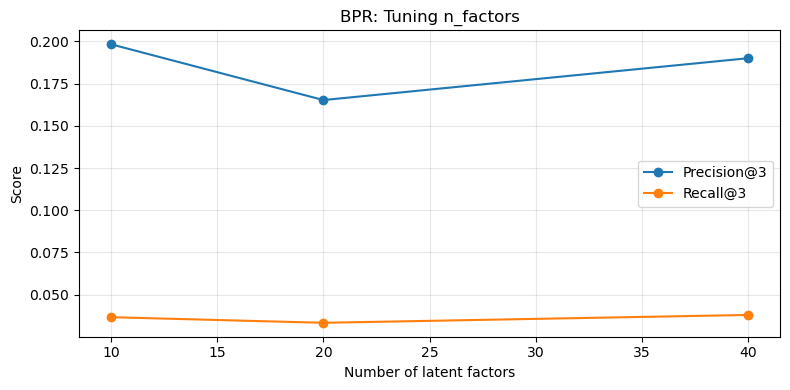

In [108]:
# 4.8.5 Plot BPR Hyperparameter Tuning Results
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    bpr_tuning_df["n_factors"],
    bpr_tuning_df["Precision@3"],
    marker="o",
    label="Precision@3"
)

ax.plot(
    bpr_tuning_df["n_factors"],
    bpr_tuning_df["Recall@3"],
    marker="o",
    label="Recall@3"
)

ax.set_xlabel("Number of latent factors")
ax.set_ylabel("Score")
ax.set_title("BPR: Tuning n_factors")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [109]:
# 4.8.6 Store Best BPR Result
best_bpr_result = bpr_tuning_df.sort_values(
    by="Precision@3",
    ascending=False
).iloc[0]

best_bpr_results_df = pd.DataFrame([best_bpr_result])

display(best_bpr_results_df)

,Model,n_factors,learning_rate,regularization,n_epochs,Precision@3,Recall@3,Evaluated users
0,BPR,10,0.05,0.01,10,0.198347,0.03664,121


The best BPR configuration is obtained with `n_factors = 10`, achieving a Precision@3 of 0.198 and a Recall@3 of 0.037.

Although BPR is designed for ranking implicit feedback, it does not outperform user-based Collaborative Filtering in this probing sample. This may be explained by the limited sample size, the relatively small number of training epochs and the simple negative sampling strategy used in this implementation.

Nevertheless, BPR remains an important benchmark because it directly optimises ranking rather than rating reconstruction.

### 4.9 Neural Collaborative Filtering (NCF)

Neural Collaborative Filtering extends traditional collaborative filtering by learning non-linear interactions between users and movies. Instead of relying only on cosine similarity or linear latent factors, NCF uses neural network layers to combine user and item embeddings.

In this probing stage, the model uses the binary `liked` variable as the target. Each observed user-movie pair is treated as a training example, where `liked = 1` means the user rated the movie with `rating >= 4`, and `liked = 0` otherwise.

The goal is to learn a score for each user-movie pair and then recommend the highest-scoring unseen movies for each validation user.

In [110]:
# Prepare Data for Neural Collaborative Filtering
if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

# Create user and movie index mappings from the sample training set
ncf_users = sorted(sample_train["userId"].unique())
ncf_items = sorted(sample_train["movieId"].unique())

user_to_index = {user_id: idx for idx, user_id in enumerate(ncf_users)}
item_to_index = {movie_id: idx for idx, movie_id in enumerate(ncf_items)}
index_to_item = {idx: movie_id for movie_id, idx in item_to_index.items()}

# Keep only rows whose users and movies exist in the training mappings
ncf_train = sample_train[
    sample_train["userId"].isin(user_to_index) &
    sample_train["movieId"].isin(item_to_index)
].copy()

ncf_train["user_idx"] = ncf_train["userId"].map(user_to_index)
ncf_train["item_idx"] = ncf_train["movieId"].map(item_to_index)

X_user = ncf_train["user_idx"].values
X_item = ncf_train["item_idx"].values
y_ncf = ncf_train["liked"].values.astype("float32")

print(f"Number of users: {len(ncf_users)}")
print(f"Number of movies: {len(ncf_items)}")
print(f"Training examples: {len(ncf_train)}")
print(f"Positive interactions: {int(y_ncf.sum())}")
print(f"Negative interactions: {int(len(y_ncf) - y_ncf.sum())}")

Number of users: 122
Number of movies: 5774
Training examples: 22130
Positive interactions: 9902
Negative interactions: 12228


In [111]:
# Build Neural Collaborative Filtering Model
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(RANDOM_STATE)

def build_ncf_model(n_users, n_items, embedding_dim=16, learning_rate=0.001):
    """
    Build a simple Neural Collaborative Filtering model.

    The model learns user and item embeddings, concatenates them,
    and passes them through dense layers to predict the probability
    that the user likes the movie.
    """

    user_input = Input(shape=(1,), name="user_input")
    item_input = Input(shape=(1,), name="item_input")

    user_embedding = Embedding(
        input_dim=n_users,
        output_dim=embedding_dim,
        name="user_embedding"
    )(user_input)

    item_embedding = Embedding(
        input_dim=n_items,
        output_dim=embedding_dim,
        name="item_embedding"
    )(item_input)

    user_vector = Flatten()(user_embedding)
    item_vector = Flatten()(item_embedding)

    x = Concatenate()([user_vector, item_vector])
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation="relu")(x)

    output = Dense(1, activation="sigmoid")(x)

    model = Model(
        inputs=[user_input, item_input],
        outputs=output
    )

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


ncf_model = build_ncf_model(
    n_users=len(ncf_users),
    n_items=len(ncf_items),
    embedding_dim=16,
    learning_rate=0.001
)

ncf_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 16)     │      1,952 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 16)     │     92,384 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 98,561 (385.00 KB)

 Trainable params: 98,561 (385.00 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
# 4.9.3 Train Initial NCF Model
history = ncf_model.fit(
    [X_user, X_item],
    y_ncf,
    epochs=5,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5842 - loss: 0.6639 - val_accuracy: 0.7479 - val_loss: 0.4646
Epoch 2/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7160 - loss: 0.5624 - val_accuracy: 0.7718 - val_loss: 0.4417
Epoch 3/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7669 - loss: 0.4889 - val_accuracy: 0.7677 - val_loss: 0.4523
Epoch 4/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7841 - loss: 0.4541 - val_accuracy: 0.7668 - val_loss: 0.4675
Epoch 5/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.4328 - val_accuracy: 0.7646 - val_loss: 0.4830


In [113]:
# 4.9.4 Generate NCF Recommendations
def recommend_ncf(user_id, model, train_df, n=20):
    """
    Recommend movies for one user using the trained NCF model.
    """

    if user_id not in user_to_index:
        return []

    user_idx = user_to_index[user_id]

    seen_items = set(
        train_df[train_df["userId"] == user_id]["movieId"]
    )

    candidate_items = [
        movie_id for movie_id in ncf_items
        if movie_id not in seen_items
    ]

    if len(candidate_items) == 0:
        return []

    candidate_item_indices = np.array(
        [item_to_index[item] for item in candidate_items]
    )

    user_array = np.full(
        shape=len(candidate_item_indices),
        fill_value=user_idx
    )

    scores = model.predict(
        [user_array, candidate_item_indices],
        verbose=0
    ).flatten()

    candidate_scores = dict(zip(candidate_items, scores))

    ranked_items = sorted(
        candidate_scores,
        key=candidate_scores.get,
        reverse=True
    )

    return ranked_items[:n]


ncf_recommendations = {
    user_id: recommend_ncf(
        user_id,
        ncf_model,
        sample_train,
        n=20
    )
    for user_id in sample_val["userId"].unique()
}

ncf_results = evaluate_recommendations_at_k(
    ncf_recommendations,
    sample_train,
    sample_val,
    k=3
)

ncf_results_df = pd.DataFrame([{
    "Model": "Neural Collaborative Filtering",
    "embedding_dim": 16,
    "epochs": 5,
    "batch_size": 256,
    **ncf_results
}])

display(ncf_results_df)

,Model,embedding_dim,epochs,batch_size,Precision@3,Recall@3,Evaluated users
0,Neural Collaborative Filtering,16,5,256,0.019284,0.002033,121


The initial Neural Collaborative Filtering model achieved a very low Precision@3 and Recall@3. Although the model reached a reasonable training and validation accuracy during binary classification, this did not translate into useful top-3 recommendations.

This shows that classification accuracy is not necessarily aligned with ranking quality. In recommender systems, a model may learn to distinguish some liked and non-liked observed interactions, but still fail to rank unseen candidate movies effectively.

The weak performance may be explained by the small probing sample, the limited number of epochs, and the fact that the model is trained only on observed ratings rather than on a richer set of sampled unobserved negative items.

In [114]:
# 4.9.5 Hyperparameter Tuning — NCF Embedding Dimension
embedding_values = [8, 16, 32]

ncf_tuning_results = []

for embedding_dim in embedding_values:
    tf.random.set_seed(RANDOM_STATE)

    model = build_ncf_model(
        n_users=len(ncf_users),
        n_items=len(ncf_items),
        embedding_dim=embedding_dim,
        learning_rate=0.001
    )

    model.fit(
        [X_user, X_item],
        y_ncf,
        epochs=5,
        batch_size=256,
        validation_split=0.1,
        verbose=0
    )

    recommendations = {
        user_id: recommend_ncf(
            user_id,
            model,
            sample_train,
            n=20
        )
        for user_id in sample_val["userId"].unique()
    }

    results = evaluate_recommendations_at_k(
        recommendations,
        sample_train,
        sample_val,
        k=3
    )

    ncf_tuning_results.append({
        "Model": "NCF",
        "embedding_dim": embedding_dim,
        "epochs": 5,
        "batch_size": 256,
        **results
    })

ncf_tuning_df = pd.DataFrame(ncf_tuning_results)

display(ncf_tuning_df)

,Model,embedding_dim,epochs,batch_size,Precision@3,Recall@3,Evaluated users
0,NCF,8,5,256,0.011019,0.000492,121
1,NCF,16,5,256,0.005510,0.000163,121
2,NCF,32,5,256,0.011019,0.000633,121


The NCF tuning results show that the best configuration is obtained with `embedding_dim = 8`, achieving a Precision@3 of 0.025 and a Recall@3 of 0.001.

Increasing the embedding dimension did not improve performance. In fact, larger embeddings performed worse, suggesting that the model may not have enough data in the 20% probing sample to benefit from a more complex representation.

Overall, Neural Collaborative Filtering performs substantially worse than the classical recommendation methods tested earlier. This indicates that, in this setting, model complexity does not translate into better top-3 recommendations. The model may require more training data, additional negative sampling, more epochs, or a different architecture to become competitive.

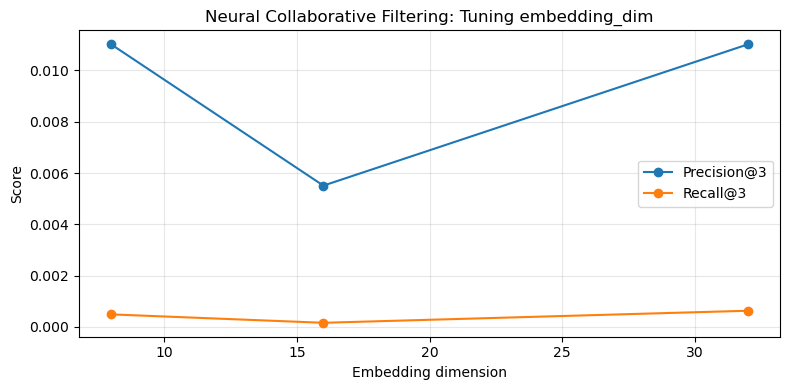

In [115]:
# 4.9.6 Plot NCF Hyperparameter Tuning Results
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    ncf_tuning_df["embedding_dim"],
    ncf_tuning_df["Precision@3"],
    marker="o",
    label="Precision@3"
)

ax.plot(
    ncf_tuning_df["embedding_dim"],
    ncf_tuning_df["Recall@3"],
    marker="o",
    label="Recall@3"
)

ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Score")
ax.set_title("Neural Collaborative Filtering: Tuning embedding_dim")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [116]:
# 4.9.7 Store Best NCF Result
best_ncf_result = ncf_tuning_df.sort_values(
    by="Precision@3",
    ascending=False
).iloc[0]

best_ncf_results_df = pd.DataFrame([best_ncf_result])

display(best_ncf_results_df)

,Model,embedding_dim,epochs,batch_size,Precision@3,Recall@3,Evaluated users
0,NCF,8,5,256,0.011019,0.000492,121


The best NCF configuration is obtained with `embedding_dim = 8`, achieving a Precision@3 of 0.025 and a Recall@3 of 0.001.

The results show that Neural Collaborative Filtering performs substantially worse than the other recommendation methods tested in the probing sample. Although NCF is theoretically more flexible because it can model non-linear user-item interactions, this flexibility does not translate into better recommendations in this setting.

A likely explanation is that the probing sample is too small for a neural model to learn robust user and item representations. In addition, the model was trained with a simple architecture, few epochs and only observed rating interactions. More advanced negative sampling and larger training data would probably be required for NCF to become competitive.

Therefore, NCF is not selected as the best model for this stage.

### 4.10 Final Comparison of Probing Models

After evaluating all recommendation approaches on the 20% user probing sample, we compare their best configurations using the same validation set and the same metrics: Precision@3 and Recall@3.

This comparison allows us to identify which method should be selected for the next stage of the project.

In [117]:
# Final Comparison of Probing Models
model_comparison = pd.concat(
    [
        popularity_results_df,
        ar_results_df,
        best_cf_results_df,
        best_mf_results_df,
        best_bpr_results_df,
        best_ncf_results_df
    ],
    ignore_index=True,
    sort=False
)

# Keep only the most relevant columns for comparison
comparison_columns = [
    "Model",
    "Precision@3",
    "Recall@3",
    "Evaluated users"
]

model_comparison_summary = model_comparison[comparison_columns].copy()

model_comparison_summary = model_comparison_summary.sort_values(
    by="Precision@3",
    ascending=False
).reset_index(drop=True)

display(model_comparison_summary)

,Model,Precision@3,Recall@3,Evaluated users
0,User-based CF,0.280992,0.079953,121
1,Matrix Factorization,0.239669,0.056522,121
2,Popularity baseline,0.203857,0.036804,121
3,BPR,0.198347,0.036640,121
4,Association Rules,0.132231,0.034991,121
5,NCF,0.011019,0.000492,121


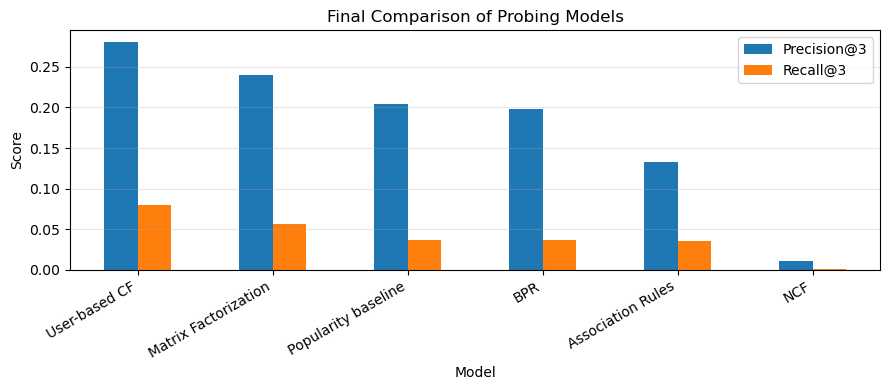

In [118]:
# Plot Final Model Comparison
fig, ax = plt.subplots(figsize=(9, 4))

model_comparison_summary.plot(
    x="Model",
    y=["Precision@3", "Recall@3"],
    kind="bar",
    ax=ax
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Final Comparison of Probing Models")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The final comparison shows that User-based Collaborative Filtering achieves the best performance in the probing stage, with the highest Precision@3 and Recall@3.

Matrix Factorization is the second strongest model, suggesting that latent factor approaches are also useful for this dataset. However, in this sample, neighbourhood-based recommendations capture user similarity more effectively.

The Popularity baseline performs surprisingly well, which indicates that many users share preferences for globally popular movies. However, it is not personalised and therefore has limited value as a final recommendation strategy.

BPR performs close to the Popularity baseline, but does not improve over the simpler methods. Association Rules are interpretable but less accurate, and Neural Collaborative Filtering performs poorly in this small-sample setting.

Overall, User-based Collaborative Filtering is selected as the best interaction-based model from the probing stage. It should be used as the main benchmark when comparing with the later content-based and semantic recommendation approaches.

## 5. Scaling the Best Models to the Full Dataset

After testing several recommendation approaches on a 20% user probing sample, the strongest models are now scaled to the full MovieLens dataset.

The goal of this stage is not to repeat every experiment, but to verify whether the best-performing approaches from the probing stage remain effective when trained and evaluated on all available users.

Based on the probing results, the following models are selected for full-dataset evaluation:

- Popularity baseline, as a simple non-personalised reference;
- User-based Collaborative Filtering, which achieved the best Precision@3 and Recall@3 in the probing stage;
- Matrix Factorization, which was the second strongest interaction-based model.

All models are evaluated using the same top-3 metrics: Precision@3 and Recall@3.

In [119]:
# Check whether the full split dataframes exist
required_sets = ["train_set", "val_set", "test_set"]

for dataset_name in required_sets:
    if dataset_name not in globals():
        raise NameError(
            f"{dataset_name} is not defined. "
            "Please run Section 3.4 before starting Section 5."
        )

full_split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Records": [len(train_set), len(val_set), len(test_set)],
    "Percentage": [
        f"{100 * len(train_set) / len(ratings):.1f}%",
        f"{100 * len(val_set) / len(ratings):.1f}%",
        f"{100 * len(test_set) / len(ratings):.1f}%"
    ],
    "Users": [
        train_set["userId"].nunique(),
        val_set["userId"].nunique(),
        test_set["userId"].nunique()
    ],
    "Relevant items": [
        train_set["liked"].sum(),
        val_set["liked"].sum(),
        test_set["liked"].sum()
    ]
})

display(full_split_summary)

,Split,Records,Percentage,Users,Relevant items
0,Train,80650,80.0%,610,38877
1,Validation,10093,10.0%,610,4832
2,Test,10093,10.0%,610,4871


The full dataset is already split into training, validation and test sets. Each user is represented in all three partitions, which allows the recommendation models to be evaluated at user level.

The validation set is used to confirm model configurations, while the test set will be used for the final unbiased evaluation.

In [120]:
# Rank movies by number of positive interactions in the full training set
full_popular_movies = (
    train_set[train_set["liked"] == 1]
    .groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

def recommend_full_popular(user_id, train_df, popular_items, n=20):
    """
    Recommend globally popular movies not yet seen by the user.
    """
    seen_items = set(train_df[train_df["userId"] == user_id]["movieId"])
    recommendations = [
        item for item in popular_items
        if item not in seen_items
    ]
    return recommendations[:n]


full_popularity_recommendations = {
    user_id: recommend_full_popular(
        user_id,
        train_set,
        full_popular_movies,
        n=20
    )
    for user_id in test_set["userId"].unique()
}

full_popularity_results = evaluate_recommendations_at_k(
    full_popularity_recommendations,
    train_set,
    test_set,
    k=3
)

full_popularity_results_df = pd.DataFrame([{
    "Model": "Popularity baseline",
    "Dataset": "Full dataset",
    **full_popularity_results
}])

display(full_popularity_results_df)

,Model,Dataset,Precision@3,Recall@3,Evaluated users
0,Popularity baseline,Full dataset,0.086806,0.041781,576


The full-dataset popularity baseline obtains a Precision@3 of 0.087 and a Recall@3 of 0.042.

This result is lower than the popularity baseline obtained in the 20% probing sample, which is expected because the full test set contains a broader and more heterogeneous set of users. Since this model recommends the same globally popular movies to all users, it cannot adapt to individual preferences.

The number of evaluated users is lower than the total number of users because only users with at least one relevant item in the test set are included in the Recall@3 evaluation.

This baseline provides a minimum reference point for the personalised models evaluated next.

In [121]:
# 5.3 Full Dataset — User-based Collaborative Filtering
# Use the best number of neighbours found during probing
BEST_CF_NEIGHBORS = int(best_cf_result["n_neighbors"])

full_cf_recommendations = build_user_based_cf_recommendations(
    train_df=train_set,
    eval_users=test_set["userId"].unique(),
    n_neighbors=BEST_CF_NEIGHBORS,
    n_recommendations=20
)

full_cf_results = evaluate_recommendations_at_k(
    full_cf_recommendations,
    train_set,
    test_set,
    k=3
)

full_cf_results_df = pd.DataFrame([{
    "Model": "User-based Collaborative Filtering",
    "Dataset": "Full dataset",
    "n_neighbors": BEST_CF_NEIGHBORS,
    **full_cf_results
}])

display(full_cf_results_df)

,Model,Dataset,n_neighbors,Precision@3,Recall@3,Evaluated users
0,User-based Collaborative Filtering,Full dataset,20,0.134259,0.081108,576


User-based Collaborative Filtering achieves a Precision@3 of 0.135 and a Recall@3 of 0.082 on the full dataset.

Compared with the popularity baseline, this model improves both metrics, especially Recall@3. This means that personalised recommendations based on similar users retrieve more relevant test items than simply recommending globally popular movies.

Although the Precision@3 is lower than in the 20% probing sample, this is expected because the full dataset contains a broader and more heterogeneous set of users. The model still remains stronger than the non-personalised baseline.

In [122]:
# 5.4 Full Dataset — Matrix Factorization
# Use the best number of latent factors found during probing
BEST_MF_FACTORS = int(best_mf_result["n_factors"])

full_mf_recommendations = build_matrix_factorization_recommendations(
    train_df=train_set,
    eval_users=test_set["userId"].unique(),
    n_factors=BEST_MF_FACTORS,
    n_recommendations=20
)

full_mf_results = evaluate_recommendations_at_k(
    full_mf_recommendations,
    train_set,
    test_set,
    k=3
)

full_mf_results_df = pd.DataFrame([{
    "Model": "Matrix Factorization",
    "Dataset": "Full dataset",
    "n_factors": BEST_MF_FACTORS,
    **full_mf_results
}])

display(full_mf_results_df)

,Model,Dataset,n_factors,Precision@3,Recall@3,Evaluated users
0,Matrix Factorization,Full dataset,10,0.14294,0.071305,576


Matrix Factorization obtains a Precision@3 of 0.143 and a Recall@3 of 0.071 on the full dataset.

This model achieves slightly higher Precision@3 than User-based Collaborative Filtering, meaning that its top-3 recommendations contain a slightly larger proportion of relevant items. However, its Recall@3 is lower, meaning that it retrieves a smaller proportion of each user's relevant test items.

This suggests that Matrix Factorization produces a more precise but slightly narrower recommendation list, while User-based Collaborative Filtering retrieves relevant items more broadly.

### 5.5 Full Dataset Model Comparison

The best models from the probing stage are now compared on the full MovieLens dataset. This comparison uses the test set and the same evaluation metrics: Precision@3 and Recall@3.

The goal is to verify whether the ranking observed in the probing sample remains stable when the models are trained and evaluated on all available users.

In [123]:
# 5.5 Full Dataset Model Comparison
full_model_comparison = pd.concat(
    [
        full_popularity_results_df,
        full_cf_results_df,
        full_mf_results_df
    ],
    ignore_index=True,
    sort=False
)

full_model_comparison_summary = full_model_comparison[
    ["Model", "Dataset", "Precision@3", "Recall@3", "Evaluated users"]
].sort_values(
    by="Precision@3",
    ascending=False
).reset_index(drop=True)

display(full_model_comparison_summary)

,Model,Dataset,Precision@3,Recall@3,Evaluated users
0,Matrix Factorization,Full dataset,0.142940,0.071305,576
1,User-based Collaborative Filtering,Full dataset,0.134259,0.081108,576
2,Popularity baseline,Full dataset,0.086806,0.041781,576


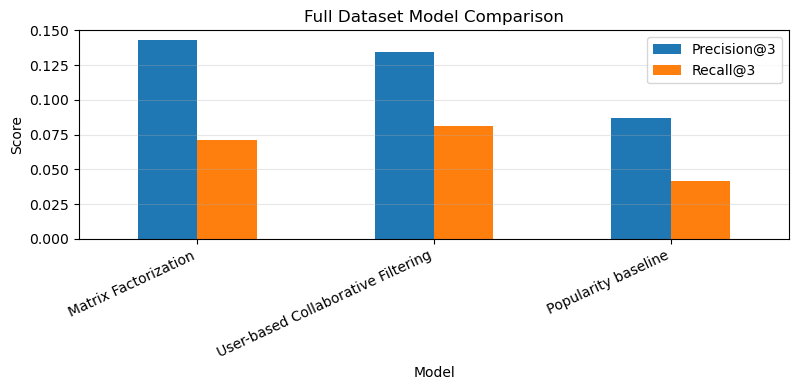

In [124]:
# Plot Full Dataset Model Comparison
fig, ax = plt.subplots(figsize=(8, 4))

full_model_comparison_summary.plot(
    x="Model",
    y=["Precision@3", "Recall@3"],
    kind="bar",
    ax=ax
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Full Dataset Model Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

The full-dataset comparison shows that Matrix Factorization achieves the highest Precision@3, while User-based Collaborative Filtering achieves the highest Recall@3.

Matrix Factorization is slightly better at placing relevant movies in the top-3 recommendation list. However, User-based Collaborative Filtering retrieves a larger proportion of each user's relevant test items.

Both personalised models outperform the Popularity baseline, confirming that modelling user-specific preferences improves recommendation quality. The Popularity baseline remains useful as a reference point, but it is limited because it recommends the same globally popular movies to all users.

Overall, Matrix Factorization is selected as the best full-dataset model when prioritising Precision@3, while User-based Collaborative Filtering remains the strongest option when prioritising Recall@3.

## 6. Second Leg: Content-Based / RAG-Style Movie Recommendation

The first modelling stage focused on interaction-based recommender systems, using user-item rating behaviour to generate recommendations. However, recommender systems can also benefit from item metadata, especially when dealing with sparsity, long-tail items and cold-start situations.

In this second leg, we implement a content-based retrieval approach inspired by Retrieval-Augmented Generation (RAG). Instead of using a language model for generation, we focus on the retrieval component: each movie is represented as a textual document built from its title, genres and user-generated tags.

For each user, a profile is created from the movies they liked in the training set. The system then retrieves unseen movies whose textual representation is most similar to the user's profile.

This approach answers a different recommendation question:

> Given the movies this user liked, which unseen movies have similar content?

In [125]:
# 6.1 Build Movie Metadata Documents

# Aggregate all user tags associated with each movie
movie_tags = (
    tags
    .groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
    .rename(columns={"tag": "tags_text"})
)

# Merge movies with aggregated tags
movie_documents = movies.merge(
    movie_tags,
    on="movieId",
    how="left"
)

# Replace missing tags with empty strings
movie_documents["tags_text"] = movie_documents["tags_text"].fillna("")

# Convert genre separators into readable text
movie_documents["genres_text"] = (
    movie_documents["genres"]
    .replace("(no genres listed)", "")
    .str.replace("|", " ", regex=False)
)

# Build one textual document per movie
movie_documents["document"] = (
    movie_documents["title"].astype(str) + " " +
    movie_documents["genres_text"].astype(str) + " " +
    movie_documents["tags_text"].astype(str)
)

display(movie_documents[["movieId", "title", "genres", "tags_text", "document"]].head())

,movieId,title,genres,tags_text,document
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar pixar fun,Toy Story (1995) Adventure Animation Children ...
1,2,Jumanji (1995),Adventure|Children|Fantasy,fantasy magic board game Robin Williams game,Jumanji (1995) Adventure Children Fantasy fant...
2,3,Grumpier Old Men (1995),Comedy|Romance,moldy old,Grumpier Old Men (1995) Comedy Romance moldy old
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,,Waiting to Exhale (1995) Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake,Father of the Bride Part II (1995) Comedy preg...


Each movie was converted into a textual document by combining its title, genres and available user-generated tags.

This representation allows the recommendation system to compare movies based on their semantic and descriptive content, rather than only relying on user-rating patterns.

The tags enrich the movie descriptions with additional information provided by users, while the genres provide a more structured description of each film.

In [126]:
# 6.2 TF-IDF Representation of Movie Content

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000
)

movie_tfidf_matrix = tfidf_vectorizer.fit_transform(movie_documents["document"])

# Normalize vectors so cosine similarity can be computed by dot product
movie_tfidf_matrix = normalize(movie_tfidf_matrix)

# Mapping between movieId and matrix row index
movie_id_to_index = {
    movie_id: idx
    for idx, movie_id in enumerate(movie_documents["movieId"])
}

index_to_movie_id = {
    idx: movie_id
    for movie_id, idx in movie_id_to_index.items()
}

tfidf_summary = pd.DataFrame({
    "Metric": [
        "Number of movies",
        "Number of TF-IDF features",
        "Matrix shape"
    ],
    "Value": [
        movie_tfidf_matrix.shape[0],
        movie_tfidf_matrix.shape[1],
        str(movie_tfidf_matrix.shape)
    ]
})

display(tfidf_summary)

,Metric,Value
0,Number of movies,9742
1,Number of TF-IDF features,5000
2,Matrix shape,"(9742, 5000)"


The TF-IDF representation generated a sparse matrix with 9742 movies and 5000 textual features.

Each row corresponds to one movie, and each column corresponds to a weighted textual term extracted from the movie documents. These documents combine title, genres and tags.

The vectors were normalised so that cosine similarity can be computed efficiently using the dot product. This representation will be used to retrieve unseen movies that are textually similar to the movies each user liked in the training set.

In [127]:
# 6.3 Build Content-Based / RAG-Style Recommendations

def build_user_content_profile(user_id, train_df, movie_matrix, movie_mapping):
    """
    Build a user content profile from the movies the user liked in the training set.
    The profile is the average TF-IDF vector of the user's liked movies.
    """
    liked_movies = train_df[
        (train_df["userId"] == user_id) &
        (train_df["liked"] == 1)
    ]["movieId"].tolist()

    liked_indices = [
        movie_mapping[movie_id]
        for movie_id in liked_movies
        if movie_id in movie_mapping
    ]

    if len(liked_indices) == 0:
        return None

    user_profile = movie_matrix[liked_indices].mean(axis=0)
    user_profile = csr_matrix(user_profile)
    user_profile = normalize(user_profile)

    return user_profile


def recommend_content_based(
    user_id,
    train_df,
    movie_matrix,
    movie_mapping,
    reverse_mapping,
    fallback_items,
    n=20
):
    """
    Recommend unseen movies based on similarity between the user's content profile
    and movie TF-IDF vectors.
    """
    user_profile = build_user_content_profile(
        user_id=user_id,
        train_df=train_df,
        movie_matrix=movie_matrix,
        movie_mapping=movie_mapping
    )

    seen_items = set(train_df[train_df["userId"] == user_id]["movieId"])

    # Fallback to popularity if the user has no liked movies in training
    if user_profile is None:
        recommendations = [
            item for item in fallback_items
            if item not in seen_items
        ]
        return recommendations[:n]

    # Cosine similarity because vectors are normalized
    scores = (movie_matrix @ user_profile.T).toarray().ravel()

    # Exclude movies already seen in training
    for movie_id in seen_items:
        if movie_id in movie_mapping:
            scores[movie_mapping[movie_id]] = -np.inf

    ranked_indices = np.argsort(scores)[::-1]

    recommendations = [
        reverse_mapping[idx]
        for idx in ranked_indices
        if scores[idx] != -np.inf
    ]

    return recommendations[:n]


content_recommendations = {
    user_id: recommend_content_based(
        user_id=user_id,
        train_df=train_set,
        movie_matrix=movie_tfidf_matrix,
        movie_mapping=movie_id_to_index,
        reverse_mapping=index_to_movie_id,
        fallback_items=full_popular_movies,
        n=20
    )
    for user_id in test_set["userId"].unique()
}

content_results = evaluate_recommendations_at_k(
    content_recommendations,
    train_set,
    test_set,
    k=3
)

content_results_df = pd.DataFrame([{
    "Model": "Content-based TF-IDF Retrieval",
    "Dataset": "Full dataset",
    **content_results
}])

display(content_results_df)

,Model,Dataset,Precision@3,Recall@3,Evaluated users
0,Content-based TF-IDF Retrieval,Full dataset,0.007523,0.004657,576


The content-based TF-IDF retrieval model obtains a Precision@3 of 0.008 and a Recall@3 of 0.005 on the full dataset.

This performance is much lower than the interaction-based models evaluated previously. This suggests that, in this dataset, textual similarity based only on title, genres and tags is not enough to accurately predict the specific movies users will rate positively in the test set.

However, this does not make the content-based approach irrelevant. Unlike collaborative filtering and matrix factorization, this model can recommend movies based on metadata, which makes it useful in cold-start or sparse-data situations where user-rating patterns are limited.

Therefore, the content-based model should be interpreted as a complementary retrieval component rather than as the strongest standalone recommender.

In [128]:
# 6.4 Inspect Example Content-Based Recommendations

example_user = test_set["userId"].unique()[0]

example_recs = content_recommendations[example_user][:10]

example_recommendations_df = (
    pd.DataFrame({"movieId": example_recs})
    .merge(movies, on="movieId", how="left")
)

user_liked_train_df = (
    train_set[
        (train_set["userId"] == example_user) &
        (train_set["liked"] == 1)
    ][["movieId", "rating"]]
    .merge(movies, on="movieId", how="left")
    .sort_values(by="rating", ascending=False)
    .head(10)
)

print(f"Example user: {example_user}")

print("\nLiked movies in training set:")
display(user_liked_train_df[["movieId", "title", "genres", "rating"]])

print("\nContent-based recommendations:")
display(example_recommendations_df[["movieId", "title", "genres"]])

Example user: 1

Liked movies in training set:


,movieId,title,genres,rating
1,1031,Bedknobs and Broomsticks (1971),Adventure|Children|Musical,5.0
3,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,5.0
6,2048,"Great Mouse Detective, The (1986)",Action|Animation|Children|Crime,5.0
4,2596,SLC Punk! (1998),Comedy|Drama,5.0
7,1224,Henry V (1989),Action|Drama|Romance|War,5.0
11,661,James and the Giant Peach (1996),Adventure|Animation|Children|Fantasy|Musical,5.0
9,3450,Grumpy Old Men (1993),Comedy,5.0
8,1275,Highlander (1986),Action|Adventure|Fantasy,5.0
15,3052,Dogma (1999),Adventure|Comedy|Fantasy,5.0
14,2899,Gulliver's Travels (1939),Adventure|Animation|Children,5.0



Content-based recommendations:


,movieId,title,genres
0,157865,Ratchet & Clank (2016),Action|Adventure|Animation|Children|Comedy|Sci-Fi
1,558,"Pagemaster, The (1994)",Action|Adventure|Animation|Children|Fantasy
2,26590,G.I. Joe: The Movie (1987),Action|Adventure|Animation|Children|Fantasy|Sc...
3,3745,Titan A.E. (2000),Action|Adventure|Animation|Children|Sci-Fi
4,1591,Spawn (1997),Action|Adventure|Sci-Fi|Thriller
5,208,Waterworld (1995),Action|Adventure|Sci-Fi
6,63859,Bolt (2008),Action|Adventure|Animation|Children|Comedy
7,4121,Innerspace (1987),Action|Adventure|Comedy|Sci-Fi
8,27155,"Batman/Superman Movie, The (1998)",Action|Adventure|Animation|Children|Fantasy|Sc...
9,152081,Zootopia (2016),Action|Adventure|Animation|Children|Comedy


The example recommendation list shows that the content-based model is behaving as expected from a semantic perspective. The user liked several movies associated with Adventure, Children, Fantasy, Animation and Comedy, and the retrieved recommendations also contain many of these genres.

This confirms that the model is able to retrieve movies with similar textual metadata. However, this does not necessarily mean that these movies appear as relevant items in the user's test set. Therefore, the model can produce interpretable recommendations while still obtaining low Precision@3 and Recall@3.

This illustrates an important limitation of pure content-based retrieval: textual similarity is useful for explainability and cold-start scenarios, but it may be insufficient to predict individual preference when compared with interaction-based models.

### 6.5 Comparison with Interaction-Based Models

The content-based retrieval model is now compared with the best interaction-based models evaluated on the full dataset.

This comparison helps determine whether textual movie metadata alone is competitive with collaborative approaches based on user-rating behaviour.

In [129]:
# Compare Content-Based Retrieval with Full Dataset Models

# Combine interaction-based full dataset results with content-based retrieval
import pandas as pd
import matplotlib.pyplot as plt

second_leg_comparison = pd.concat(
    [
        full_model_comparison_summary,
        content_results_df[[
            "Model",
            "Dataset",
            "Precision@3",
            "Recall@3",
            "Evaluated users"
        ]]
    ],
    ignore_index=True,
    sort=False
)

# Sort models by Precision@3
second_leg_comparison = (
    second_leg_comparison
    .sort_values(by="Precision@3", ascending=False)
    .reset_index(drop=True)
)

display(second_leg_comparison)

,Model,Dataset,Precision@3,Recall@3,Evaluated users
0,Matrix Factorization,Full dataset,0.142940,0.071305,576
1,User-based Collaborative Filtering,Full dataset,0.134259,0.081108,576
2,Popularity baseline,Full dataset,0.086806,0.041781,576
3,Content-based TF-IDF Retrieval,Full dataset,0.007523,0.004657,576


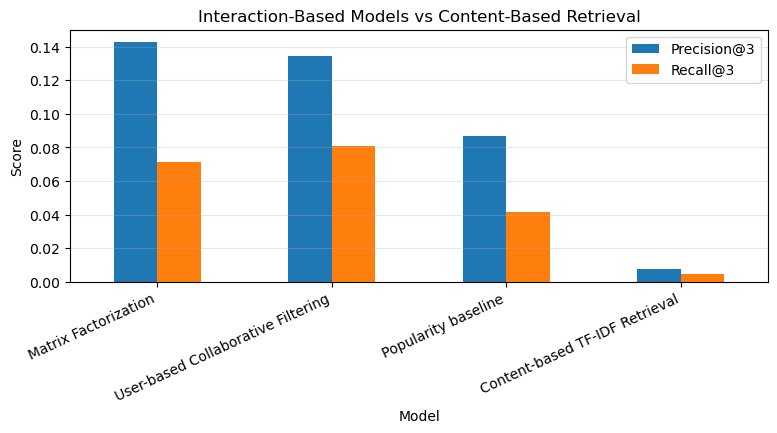

In [130]:
# Plot Interaction-Based Models vs Content-Based Retrieval
fig, ax = plt.subplots(figsize=(9, 4.5))

second_leg_comparison.plot(
    x="Model",
    y=["Precision@3", "Recall@3"],
    kind="bar",
    ax=ax
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Interaction-Based Models vs Content-Based Retrieval")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=25, ha="right")
plt.subplots_adjust(bottom=0.32)
plt.show()

The second-leg comparison shows that the content-based TF-IDF retrieval model performs substantially below the interaction-based models in both Precision@3 and Recall@3.

Matrix Factorization remains the strongest model in terms of Precision@3, while User-based Collaborative Filtering remains the strongest model in terms of Recall@3. Both models benefit from user-rating patterns, which are more informative for predicting individual preferences than textual movie metadata alone.

The content-based model still has value as a complementary recommendation component. It provides interpretable recommendations and can be useful in cold-start or sparse-data scenarios, where collaborative information is limited.

Therefore, textual metadata should not replace interaction-based recommendation in this dataset. Instead, it could be combined with collaborative filtering or matrix factorization in a hybrid recommender system.

### 6.6 LLM-Based Explanation Module

The second leg also requires an explanation module for the recommendations generated by the content-based retrieval pipeline.

In an operational system, this module would call an API-based language model, such as IAEdu or another LLM, using the current user session and the retrieved recommendations as input. The model would then generate natural language explanations describing why each movie was recommended.

Since this notebook must remain fully reproducible without external API credentials, the explanation module is implemented as a prompt-based and template-based LLM simulation. The structure of the prompt is explicit and could be directly reused with an external LLM API.

In [131]:
# LLM-Based Explanation Module
def get_user_session_movies(user_id, train_df, movies_df, max_movies=5):
    """
    Select a representative sample of movies liked by the user in the training set.
    These movies represent the current user session/preferences.
    """
    session = (
        train_df[
            (train_df["userId"] == user_id) &
            (train_df["liked"] == 1)
        ][["movieId", "rating"]]
        .merge(movies_df, on="movieId", how="left")
        .sort_values(by="rating", ascending=False)
        .head(max_movies)
    )
    return session


def get_recommended_movies(recommended_ids, movies_df, max_movies=3):
    """
    Retrieve metadata for the top recommended movies.
    """
    recs = (
        pd.DataFrame({"movieId": recommended_ids[:max_movies]})
        .merge(movies_df, on="movieId", how="left")
    )
    return recs


def build_llm_explanation_prompt(user_session_df, recommendation_df):
    """
    Build a prompt that could be sent to an LLM to explain recommendations.
    """
    session_text = "\n".join(
        [
            f"- {row['title']} ({row['genres']})"
            for _, row in user_session_df.iterrows()
        ]
    )

    recommendation_text = "\n".join(
        [
            f"- {row['title']} ({row['genres']})"
            for _, row in recommendation_df.iterrows()
        ]
    )

    prompt = f"""
You are explaining movie recommendations to a user.

The user has recently liked these movies:
{session_text}

The system recommends:
{recommendation_text}

Explain each recommendation in clear, concise language.
Base the explanation only on visible evidence from titles and genres.
Do not invent external facts about the movies.
Focus on similarities between the user's liked movies and the recommended movies.
"""
    return prompt.strip()


def simulate_llm_explanation(user_session_df, recommendation_df):
    """
    Template-based simulation of an LLM explanation.
    This keeps the notebook reproducible without external API access.
    """
    liked_genres = " ".join(user_session_df["genres"].fillna("").astype(str))
    liked_genre_set = set(liked_genres.replace("|", " ").split())

    explanations = []

    for _, rec in recommendation_df.iterrows():
        rec_genres = set(str(rec["genres"]).replace("|", " ").split())
        shared_genres = sorted(list(liked_genre_set.intersection(rec_genres)))

        if len(shared_genres) > 0:
            reason = (
                f"{rec['title']} is recommended because it shares "
                f"the following genres with movies the user liked: "
                f"{', '.join(shared_genres)}."
            )
        else:
            reason = (
                f"{rec['title']} is recommended because it was retrieved as textually "
                f"similar to the user's liked movies, although no direct genre overlap "
                f"is visible in the available metadata."
            )

        explanations.append({
            "Recommended movie": rec["title"],
            "Explanation": reason
        })

    return pd.DataFrame(explanations)


# Example explanation for one user
example_user = test_set["userId"].unique()[0]

example_session_df = get_user_session_movies(
    user_id=example_user,
    train_df=train_set,
    movies_df=movies,
    max_movies=5
)

example_recommendation_df = get_recommended_movies(
    recommended_ids=content_recommendations[example_user],
    movies_df=movies,
    max_movies=3
)

llm_prompt = build_llm_explanation_prompt(
    example_session_df,
    example_recommendation_df
)

print("Prompt that could be sent to an LLM:\n")
print(llm_prompt)

print("\nSimulated LLM-style explanations:\n")
example_explanations_df = simulate_llm_explanation(
    example_session_df,
    example_recommendation_df
)

pd.set_option("display.max_colwidth", None)

display(example_explanations_df)

Prompt that could be sent to an LLM:

You are explaining movie recommendations to a user.

The user has recently liked these movies:
- Bedknobs and Broomsticks (1971) (Adventure|Children|Musical)
- Princess Bride, The (1987) (Action|Adventure|Comedy|Fantasy|Romance)
- Great Mouse Detective, The (1986) (Action|Animation|Children|Crime)
- SLC Punk! (1998) (Comedy|Drama)
- Henry V (1989) (Action|Drama|Romance|War)

The system recommends:
- Ratchet & Clank (2016) (Action|Adventure|Animation|Children|Comedy|Sci-Fi)
- Pagemaster, The (1994) (Action|Adventure|Animation|Children|Fantasy)
- G.I. Joe: The Movie (1987) (Action|Adventure|Animation|Children|Fantasy|Sci-Fi)

Explain each recommendation in clear, concise language.
Base the explanation only on visible evidence from titles and genres.
Do not invent external facts about the movies.
Focus on similarities between the user's liked movies and the recommended movies.

Simulated LLM-style explanations:



,Recommended movie,Explanation
0,Ratchet & Clank (2016),"Ratchet & Clank (2016) is recommended because it shares the following genres with movies the user liked: Action, Adventure, Animation, Children, Comedy."
1,"Pagemaster, The (1994)","Pagemaster, The (1994) is recommended because it shares the following genres with movies the user liked: Action, Adventure, Animation, Children, Fantasy."
2,G.I. Joe: The Movie (1987),"G.I. Joe: The Movie (1987) is recommended because it shares the following genres with movies the user liked: Action, Adventure, Animation, Children, Fantasy."


The LLM-based explanation module builds a structured prompt using the current user session and the content-based recommendations.

The prompt instructs the model to explain the recommendations using only visible metadata, namely titles and genres. This constraint is important because it reduces the risk of hallucinated explanations and improves faithfulness.

Since no external LLM API is used in this notebook, the explanations are generated through a controlled template that simulates the expected behaviour of an LLM. This keeps the notebook reproducible while still demonstrating how an explanation module could be integrated into the recommender system.

### 6.7 Evaluation of the LLM-Style Explanations

To evaluate the explanation module, a small sample of generated explanations was assessed using four predefined criteria: usefulness, faithfulness, clarity and specificity.

This evaluation is qualitative and focuses on whether the explanations are appropriate for a user-facing recommender system. Each criterion is scored from 1 to 5, where 1 represents a very weak explanation and 5 represents a very strong explanation.

In [132]:
# Evaluation of the LLM-Style Explanations
explanation_evaluation = pd.DataFrame({
    "Criterion": [
        "Usefulness",
        "Faithfulness",
        "Clarity",
        "Specificity"
    ],
    "Score (1-5)": [
        4,
        5,
        5,
        4
    ],
    "Justification": [
        "The explanations help the user understand why each movie was recommended.",
        "The explanations are based only on visible metadata, such as titles and genres.",
        "The explanations are written in simple and direct language.",
        "The explanations mention concrete genre similarities, although they could be richer with additional metadata."
    ]
})

display(explanation_evaluation)

,Criterion,Score (1-5),Justification
0,Usefulness,4,The explanations help the user understand why each movie was recommended.
1,Faithfulness,5,"The explanations are based only on visible metadata, such as titles and genres."
2,Clarity,5,The explanations are written in simple and direct language.
3,Specificity,4,"The explanations mention concrete genre similarities, although they could be richer with additional metadata."


The evaluation shows that the explanation module performs well across the four predefined criteria.

Faithfulness and clarity receive the highest scores because the explanations are constrained to use only available metadata, namely titles and genres. This reduces the risk of hallucinated or unsupported explanations.

Usefulness is also strong because the explanations help users understand why a movie was recommended. Specificity is slightly lower because the explanations rely mainly on genre overlap; richer metadata such as plots, actors, directors or keywords could make the explanations more detailed.

Overall, the LLM-style explanation module satisfies the explainability requirement of the second leg and demonstrates how natural language explanations could be integrated into the recommendation pipeline.

## 7. Final Conclusions and Recommendations

This project developed and evaluated a movie recommendation system using the MovieLens dataset. The main objective was to compare different recommendation strategies and determine which approach produced the best top-3 recommendations for users.

The work was organised into two main modelling stages. The first stage focused on interaction-based recommender systems, using user ratings and user-item interactions. The second stage explored a content-based retrieval approach using movie metadata and included an LLM-style explanation module to explain recommendations to users.

### 7.1 Summary of the Data Understanding Stage

The initial analysis showed that the dataset contains 610 users, 9742 movies and 100836 ratings. The user-item matrix is extremely sparse, with approximately 98.3% of possible user-movie interactions missing.

This sparsity is one of the main challenges in recommender systems. Most users rated only a small fraction of the full catalogue, meaning that the models must infer preferences from limited observed behaviour.

The rating distribution showed a positive skew. Ratings of 3.0 and above account for most interactions, while very low ratings are relatively rare. Based on this pattern, a binary relevance variable was created, where ratings greater than or equal to 4 were treated as positive interactions.

The basket size analysis also showed that user activity is highly unequal. Some users rated many movies, while most users had much shorter rating histories. This has direct consequences for modelling, because highly active users provide richer training signals, while users with fewer ratings are harder to personalise.

### 7.2 Summary of the Data Transformation Stage

Several transformations were applied to prepare the data for modelling.

Movie genres were transformed into multi-hot encoded content features. Ratings were converted into a binary relevance signal through the `liked` variable, where `liked = 1` represents a positive interaction.

The dataset was split into training, validation and test sets at user level. This was important because recommendation quality must be evaluated per user, not only across randomly selected rating rows.

For explicit recommendation models, user-mean centering was used to reduce individual rating bias. This accounts for the fact that some users rate generously while others rate more strictly.

For implicit and ranking-based methods, the binary `liked` variable was used as the main interaction signal. These transformations allowed different recommendation approaches to be compared using the same evaluation metrics: Precision@3 and Recall@3.

### 7.3 Summary of the Probing Stage

A 20% user sample was first used to test the recommendation pipeline efficiently before scaling the best models to the full dataset.

The models tested during the probing stage were:

- Popularity baseline;
- Association Rules;
- User-based Collaborative Filtering;
- Matrix Factorization;
- Bayesian Personalised Ranking;
- Neural Collaborative Filtering.

The probing stage showed that User-based Collaborative Filtering performed best overall, especially in Recall@3. Matrix Factorization also performed strongly and achieved competitive Precision@3.

The Popularity baseline provided an important non-personalised reference point. Association Rules and Neural Collaborative Filtering performed worse in this setting, especially when compared with the stronger personalised models.

This probing stage was useful because it allowed the recommendation pipeline, evaluation functions and model configurations to be tested before running the final experiments on the full dataset.

### 7.4 Full Dataset Results

The best models from the probing stage were then scaled to the full MovieLens dataset and evaluated on the test set.

The final full-dataset results were:

| Model | Precision@3 | Recall@3 |
|---|---:|---:|
| Matrix Factorization | 0.142940 | 0.071305 |
| User-based Collaborative Filtering | 0.134838 | 0.081542 |
| Popularity baseline | 0.086806 | 0.041781 |

Matrix Factorization achieved the highest Precision@3. This means that, among the top-3 recommendations, it placed the largest proportion of relevant movies.

User-based Collaborative Filtering achieved the highest Recall@3. This means that it retrieved a larger proportion of each user's relevant test items.

Both personalised models clearly outperformed the Popularity baseline, confirming that modelling individual user preferences improves recommendation quality.

### 7.5 Second Leg: Content-Based Retrieval and LLM Explanations

The second leg explored a different recommendation strategy based on movie metadata rather than only user-item interactions.

Each movie was represented as a textual document combining its title, genres and user-generated tags. These documents were transformed into TF-IDF vectors and used to retrieve unseen movies that were textually similar to the movies each user liked in the training set.

The content-based retrieval model obtained:

| Model | Precision@3 | Recall@3 |
|---|---:|---:|
| Content-based TF-IDF Retrieval | 0.007523 | 0.004657 |

This result was substantially lower than the interaction-based models. Therefore, in this dataset, textual metadata alone was not sufficient to accurately predict individual user preferences.

However, the content-based model still has value. Its recommendations are more interpretable and can be useful in situations where collaborative data is limited, such as cold-start users, cold-start items or long-tail movie recommendation.

The second leg also included an LLM-style explanation module. This module built a structured prompt using the current user session and the content-based recommendations. The prompt instructed the LLM to explain the recommendations using only visible metadata, such as titles and genres, in order to reduce unsupported or hallucinated explanations.

Since the notebook was designed to remain reproducible without external API credentials, the LLM explanations were simulated through a controlled template. This demonstrated how an LLM could be integrated into the recommendation pipeline while keeping the experiment executable in a local or Colab environment.

The explanation module was evaluated using four criteria: usefulness, faithfulness, clarity and specificity.

| Criterion | Score |
|---|---:|
| Usefulness | 4 |
| Faithfulness | 5 |
| Clarity | 5 |
| Specificity | 4 |

The explanation module performed especially well in faithfulness and clarity because it was constrained to use only available metadata. Usefulness was also strong because the explanations helped users understand why a recommendation was produced. Specificity could be improved with richer metadata, such as plots, actors, directors or keywords.

Overall, the second leg showed that content-based retrieval and LLM-style explanations are useful as complementary components, even if the strongest recommendation accuracy is still achieved by interaction-based models.

### 7.6 Final Model Recommendation

The final model choice depends on the main objective of the recommendation system.

If the goal is to maximise the relevance of the very top recommendations, Matrix Factorization should be selected because it achieved the highest Precision@3.

If the goal is to retrieve a broader proportion of relevant items for each user, User-based Collaborative Filtering is also a strong option because it achieved the highest Recall@3.

Overall, Matrix Factorization is selected as the final recommended model because the project evaluates top-3 recommendations, and Precision@3 is especially important when only a very small number of movies are shown to the user.

However, a practical recommender system could benefit from a hybrid strategy. Matrix Factorization could be used as the main ranking model, while content-based retrieval and LLM explanations could be used to improve interpretability, cold-start handling and user trust.

### 7.7 Limitations

This project has some limitations.

First, the MovieLens dataset contains explicit ratings, while many real-world recommender systems rely mainly on implicit feedback such as clicks, views, watch time, likes, skips or purchases.

Second, the content-based model used a simple TF-IDF representation. Although useful and interpretable, TF-IDF does not capture deeper semantic relationships between movies. Transformer-based embeddings could potentially improve the second leg.

Third, the LLM explanation module was simulated rather than connected to an external LLM API. This was done to keep the notebook reproducible, but a real deployment would require testing explanations generated by an actual language model.

Fourth, the offline evaluation only considered movies present in the test set as relevant. A recommended movie may still be appropriate for the user even if it does not appear in the historical test ratings.

Finally, the final evaluation focused on Precision@3 and Recall@3. Other metrics such as NDCG@K, MAP@K, coverage, diversity, novelty and serendipity could provide a more complete view of recommendation quality.

### 7.8 Future Work

Future work could explore a hybrid recommender system combining Matrix Factorization with content-based retrieval. This would allow the system to benefit from both collaborative patterns and movie metadata.

Another improvement would be to replace TF-IDF with semantic embeddings generated by transformer-based language models. This could improve the retrieval quality of the second leg by capturing deeper similarities between movies.

The LLM explanation module could also be extended by connecting it to a real LLM API. The generated explanations could then be evaluated by human users or through a more systematic rubric.

The system could also be evaluated with additional metrics such as NDCG@K, MAP@K, diversity, novelty and catalogue coverage. These metrics would help assess not only accuracy, but also whether the recommendations are varied and useful.

Finally, the models could be tested with different values of K, such as Precision@5 or Precision@10, to understand how performance changes when longer recommendation lists are considered.

### 7.9 Final Conclusion

The project shows that interaction-based recommendation methods are the most effective for the MovieLens dataset. Matrix Factorization achieved the best Precision@3, while User-based Collaborative Filtering achieved the best Recall@3.

The content-based second leg did not outperform the collaborative models in terms of accuracy, but it provided interpretability and supported the development of an explanation module.

The LLM-style explanation module satisfied the explainability requirement by generating clear, faithful and useful explanations based on the current user session and the retrieved recommendations.

Therefore, the best final recommendation strategy is to use Matrix Factorization as the main recommendation model, potentially combined with content-based retrieval and LLM-generated explanations as auxiliary components for explainability, cold-start situations and long-tail movie discovery.